# Spectral_Analysis — part 7 of 7

This notebook was automatically split from a larger notebook.

Loaded feature sources:
  Loaded traveling-wave trajectory: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_trajectory.csv
  Loaded PLV dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_output_dict.npy
  Loaded AES dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_output_dict.npy
  Loaded resonance NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_outputs.npz
Features used: 28
Selected number of regimes: 3
Raw regime counts:
  R0: 116 windows (12.0%)
  R1: 38 windows (3.9%)
  R2: 812 windows (84.1%)
Cleaned regime counts:
  R0: 40 windows (4.1%)
  R1: 114 windows (11.8%)
  R2: 812 windows (84.1%)
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/multim

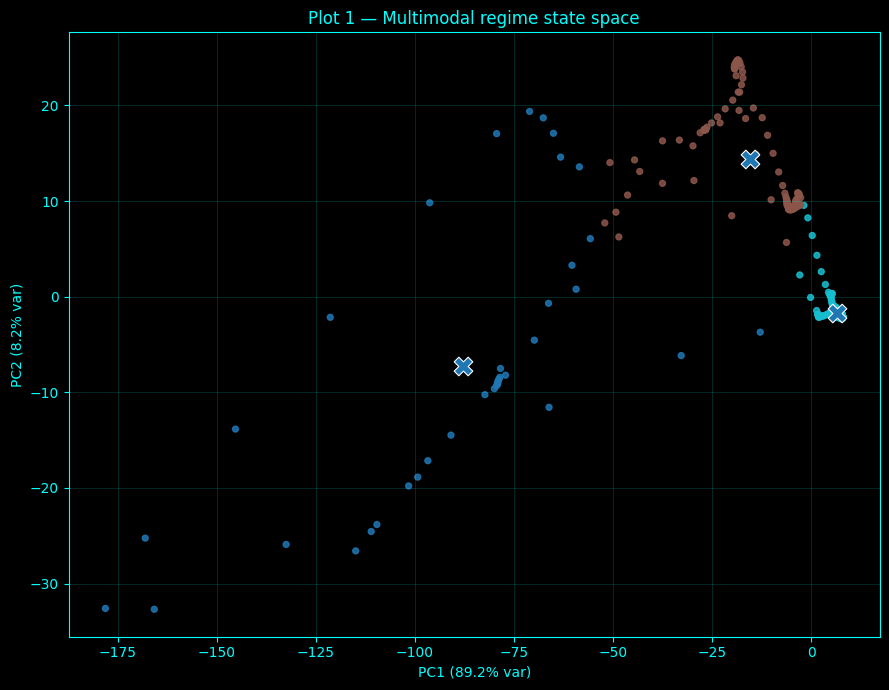

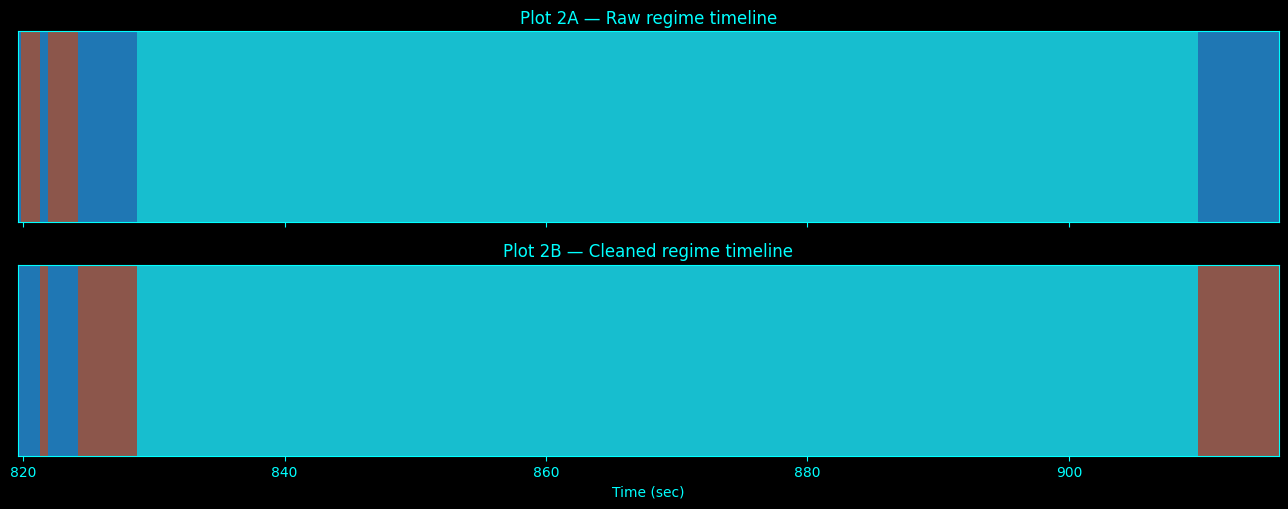

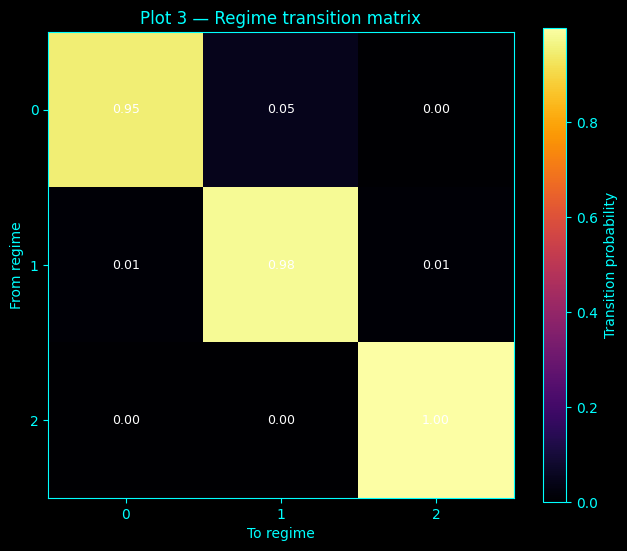

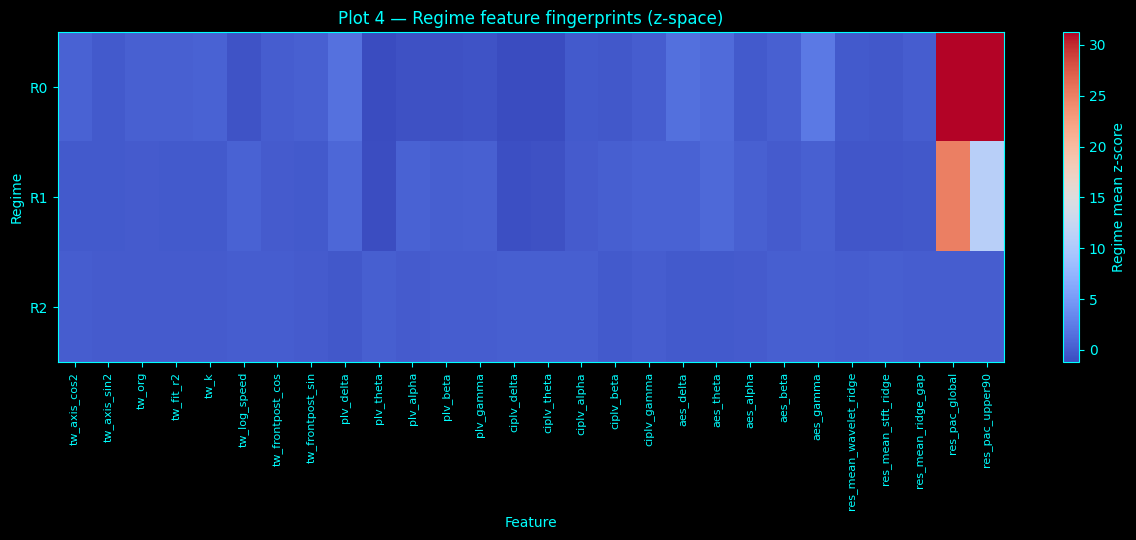

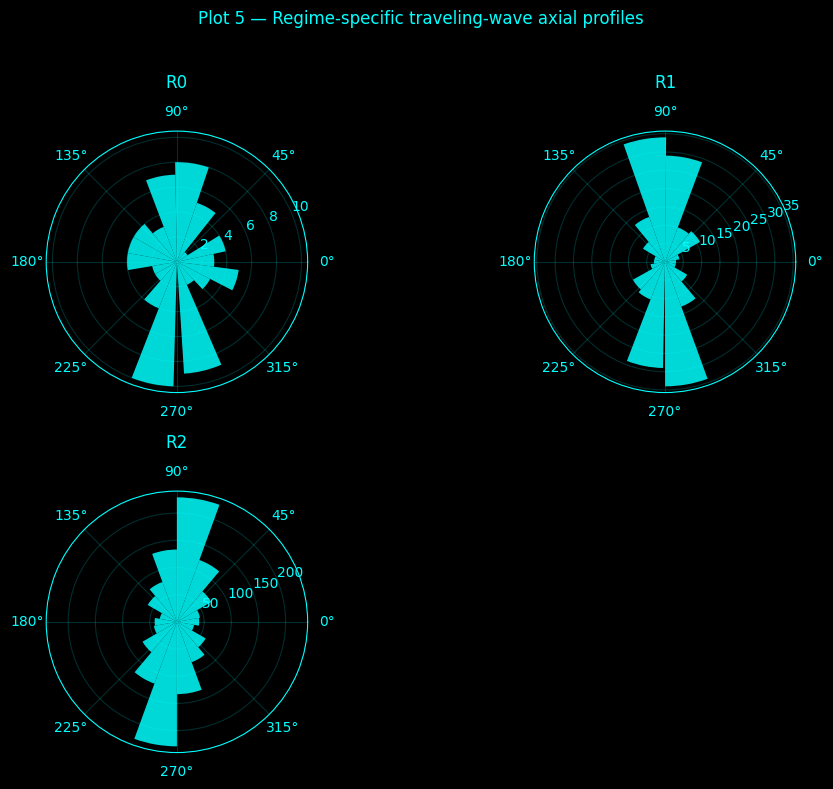

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot1_pca_regime_state_space.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot2_regime_timeline.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot3_regime_transition_matrix.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot4_regime_feature_fingerprints.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot5_regime_axial_direction_profiles.png
Done.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results")

out_dir = os.path.join(results_dir, "exploratory_multimodal_regime_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Candidate upstream outputs from earlier blocks
traveling_wave_csv_candidates = [
    os.path.join(results_dir, "exploratory_alpha_traveling_wave_atlas", "traveling_wave_trajectory.csv"),
    "/mnt/data/traveling_wave_trajectory.csv",
]

plv_dict_candidates = [
    os.path.join(results_dir, "exploratory_phase_locking_value_atlas", "plv_output_dict.npy"),
]

aes_dict_candidates = [
    os.path.join(results_dir, "exploratory_amplitude_envelope_synchrony", "aes_output_dict.npy"),
]

resonance_npz_candidates = [
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
]

# Regime settings
candidate_k_values = [3, 4, 5, 6]
default_k_if_selection_fails = 4
min_regime_duration_sec = 0.50

# Data-quality / edge handling
min_feature_valid_fraction = 0.50
min_time_valid_fraction = 0.60
edge_trim_sec = 2.0

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# IO HELPERS
# -------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def load_dict_npy(path):
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    try:
        return obj.item()
    except Exception:
        return obj

# -------------------------------------------------------
# NUMERIC HELPERS
# -------------------------------------------------------
def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def circular_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)

    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)

    t = times_old[mask]
    v = values_old[mask]
    s = np.sin(v)
    c = np.cos(v)

    s_i = np.interp(times_new, t, s, left=np.nan, right=np.nan)
    c_i = np.interp(times_new, t, c, left=np.nan, right=np.nan)
    return np.arctan2(s_i, c_i)

def linear_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)

    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)

    return np.interp(times_new, times_old[mask], values_old[mask], left=np.nan, right=np.nan)

def robust_scale_matrix(X):
    X = np.asarray(X, dtype=float)
    med = np.nanmedian(X, axis=0)
    q25 = np.nanpercentile(X, 25, axis=0)
    q75 = np.nanpercentile(X, 75, axis=0)
    iqr = q75 - q25
    sd = np.nanstd(X, axis=0)
    scale = np.where(iqr > 1e-8, iqr, np.where(sd > 1e-8, sd, 1.0))
    Z = (X - med) / scale
    return Z, med, scale

def fill_missing_columns(X):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        mask = np.isfinite(col)
        if np.sum(mask) == 0:
            continue
        if np.sum(mask) == 1:
            X[:, j] = col[mask][0]
            continue
        idx = np.arange(len(col))
        X[:, j] = np.interp(idx, idx[mask], col[mask])
    return X

def pca_svd(X, n_components=5):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = U[:, :n_components] * S[:n_components]
    loadings = Vt[:n_components].T
    ev = (S ** 2) / max(X.shape[0] - 1, 1)
    evr = ev / (np.sum(ev) + eps)
    return scores, loadings, evr[:n_components]

def calinski_harabasz_score(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    n = len(labels)
    k = len(uniq)

    if k < 2 or k >= n:
        return np.nan

    overall_mean = np.mean(X, axis=0)
    B = 0.0
    W = 0.0

    for lab in uniq:
        Xi = X[labels == lab]
        if len(Xi) == 0:
            continue
        mean_i = np.mean(Xi, axis=0)
        B += len(Xi) * np.sum((mean_i - overall_mean) ** 2)
        W += np.sum((Xi - mean_i) ** 2)

    if W <= 0:
        return np.nan

    return (B / max(k - 1, 1)) / (W / max(n - k, 1))

def relabel_by_first_appearance(labels):
    labels = np.asarray(labels, dtype=int)
    order = []
    for x in labels:
        if x not in order:
            order.append(x)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels], dtype=int)

def merge_short_runs(labels, min_run_len):
    labels = np.asarray(labels, dtype=int).copy()
    changed = True

    while changed:
        changed = False
        n = len(labels)
        start = 0

        while start < n:
            end = start + 1
            while end < n and labels[end] == labels[start]:
                end += 1

            run_len = end - start
            if run_len < min_run_len:
                left_lab = labels[start - 1] if start > 0 else None
                right_lab = labels[end] if end < n else None

                if left_lab is not None and right_lab is not None:
                    replacement = left_lab if run_len <= 2 else right_lab
                elif left_lab is not None:
                    replacement = left_lab
                elif right_lab is not None:
                    replacement = right_lab
                else:
                    replacement = labels[start]

                labels[start:end] = replacement
                changed = True
                break

            start = end

    return labels

# -------------------------------------------------------
# FEATURE LOADING
# -------------------------------------------------------
feature_series = {}
feature_notes = []
common_time = None

# ---------------------------
# traveling-wave features
# ---------------------------
travel_csv_path = first_existing(traveling_wave_csv_candidates)
if travel_csv_path is not None:
    tw = pd.read_csv(travel_csv_path)
    common_time = tw["time_sec"].values.astype(float)

    # axial encoding for direction
    theta = np.radians(tw["wave_direction_deg"].values.astype(float))
    feature_series["tw_axis_cos2"] = np.cos(2.0 * theta)
    feature_series["tw_axis_sin2"] = np.sin(2.0 * theta)

    feature_series["tw_org"] = tw["organization_score_s"].values.astype(float)
    feature_series["tw_fit_r2"] = tw["fit_r2_s"].values.astype(float)
    feature_series["tw_k"] = tw["wavenumber_rad_per_unit_s"].values.astype(float)

    speed = tw["phase_velocity_units_per_sec_s"].values.astype(float)
    finite_speed = speed[np.isfinite(speed)]
    if len(finite_speed) > 0:
        speed_clip = np.nanpercentile(finite_speed, 95)
        speed = np.where(np.isfinite(speed), np.clip(speed, 0.0, speed_clip), np.nan)
    feature_series["tw_log_speed"] = np.log1p(speed)

    phase_diff = tw["front_minus_post_phase_diff_rad"].values.astype(float)
    feature_series["tw_frontpost_cos"] = np.cos(phase_diff)
    feature_series["tw_frontpost_sin"] = np.sin(phase_diff)

    feature_notes.append(f"Loaded traveling-wave trajectory: {travel_csv_path}")

# ---------------------------
# PLV features
# ---------------------------
plv_dict_path = first_existing(plv_dict_candidates)
if plv_dict_path is not None:
    plv_dict = load_dict_npy(plv_dict_path)
    t_old = np.asarray(plv_dict["dynamic_time_sec_abs"], dtype=float)

    dyn_plv = plv_dict.get("dynamic_global_plv_dict", {})
    dyn_ciplv = plv_dict.get("dynamic_global_ciplv_dict", {})

    if common_time is None:
        common_time = t_old.copy()

    for band_name, series in dyn_plv.items():
        feature_series[f"plv_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    for band_name, series in dyn_ciplv.items():
        feature_series[f"ciplv_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    feature_notes.append(f"Loaded PLV dict: {plv_dict_path}")

# ---------------------------
# AES features
# ---------------------------
aes_dict_path = first_existing(aes_dict_candidates)
if aes_dict_path is not None:
    aes_dict = load_dict_npy(aes_dict_path)
    t_old = np.asarray(aes_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_aes = aes_dict.get("dynamic_global_dict", {})

    if common_time is None:
        common_time = t_old.copy()

    for band_name, series in dyn_aes.items():
        feature_series[f"aes_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    feature_notes.append(f"Loaded AES dict: {aes_dict_path}")

# ---------------------------
# resonance / PAC features
# ---------------------------
res_npz_path = first_existing(resonance_npz_candidates)
if res_npz_path is not None:
    R = np.load(res_npz_path, allow_pickle=True)
    t_old = np.asarray(R["common_time_sec_abs"], dtype=float)

    wavelet_ridge = np.asarray(R["wavelet_ridge_hz"], dtype=float)   # time x ch
    stft_ridge = np.asarray(R["stft_ridge_hz"], dtype=float)         # time x ch
    dynamic_pac = np.asarray(R["dynamic_pac_matrix"], dtype=float)   # time x ch

    if common_time is None:
        common_time = t_old.copy()

    mean_wavelet = np.nanmean(wavelet_ridge, axis=1)
    mean_stft = np.nanmean(stft_ridge, axis=1)
    ridge_gap = np.nanmean(np.abs(wavelet_ridge - stft_ridge), axis=1)
    pac_global = np.nanmean(dynamic_pac, axis=1)
    pac_upper = np.nanpercentile(dynamic_pac, 90, axis=1)

    feature_series["res_mean_wavelet_ridge"] = linear_interp(t_old, mean_wavelet, common_time)
    feature_series["res_mean_stft_ridge"] = linear_interp(t_old, mean_stft, common_time)
    feature_series["res_mean_ridge_gap"] = linear_interp(t_old, ridge_gap, common_time)
    feature_series["res_pac_global"] = linear_interp(t_old, pac_global, common_time)
    feature_series["res_pac_upper90"] = linear_interp(t_old, pac_upper, common_time)

    feature_notes.append(f"Loaded resonance NPZ: {res_npz_path}")

if common_time is None or len(feature_series) == 0:
    raise FileNotFoundError(
        "No upstream feature files found. Run the traveling-wave block first, "
        "and optionally the PLV/AES/resonance blocks."
    )

# -------------------------------------------------------
# BUILD FEATURE TABLE
# -------------------------------------------------------
feature_df = pd.DataFrame({"time_sec": common_time})
for name, series in feature_series.items():
    feature_df[name] = np.asarray(series, dtype=float)

feature_cols = [c for c in feature_df.columns if c != "time_sec"]

# feature validity filter
valid_frac_by_feature = feature_df[feature_cols].notna().mean(axis=0)
feature_cols = [c for c in feature_cols if valid_frac_by_feature[c] >= min_feature_valid_fraction]
feature_df = feature_df[["time_sec"] + feature_cols].copy()

# time validity filter
valid_frac_by_time = feature_df[feature_cols].notna().mean(axis=1)
keep_time_mask = valid_frac_by_time >= min_time_valid_fraction
feature_df = feature_df.loc[keep_time_mask].reset_index(drop=True)

# trim edges to suppress interpolation / boundary artifacts
tmin = feature_df["time_sec"].min()
tmax = feature_df["time_sec"].max()
edge_keep = (
    (feature_df["time_sec"] >= tmin + edge_trim_sec) &
    (feature_df["time_sec"] <= tmax - edge_trim_sec)
)
feature_df = feature_df.loc[edge_keep].reset_index(drop=True)

common_time = feature_df["time_sec"].values.astype(float)
X_raw = feature_df[feature_cols].values.astype(float)

if X_raw.shape[0] < 20 or X_raw.shape[1] < 2:
    raise ValueError("Not enough valid multimodal data left after filtering to build a regime atlas.")

# fill missing
X_filled = fill_missing_columns(X_raw)

# light temporal smoothing before clustering
for j in range(X_filled.shape[1]):
    X_filled[:, j] = smooth_1d(X_filled[:, j], win=5)

# robust scaling
X_scaled, feat_med, feat_scale = robust_scale_matrix(X_filled)

# PCA
n_components = min(5, X_scaled.shape[1], X_scaled.shape[0])
scores, loadings, evr = pca_svd(X_scaled, n_components=n_components)

# -------------------------------------------------------
# REGIME SELECTION
# -------------------------------------------------------
best_k = None
best_labels = None
best_score = -np.inf

pc_use = min(4, n_components)
X_cluster = scores[:, :pc_use]

for k in candidate_k_values:
    if k >= len(X_cluster):
        continue
    try:
        centroids, labels = kmeans2(X_cluster, k, minit="points", iter=60)
        ch = calinski_harabasz_score(X_cluster, labels)
        if np.isfinite(ch) and ch > best_score:
            best_score = ch
            best_k = k
            best_labels = labels.copy()
    except Exception:
        pass

if best_labels is None:
    _, labels = kmeans2(X_cluster, default_k_if_selection_fails, minit="points", iter=60)
    best_k = default_k_if_selection_fails
    best_labels = labels.copy()

# preserve raw labels
labels_raw = relabel_by_first_appearance(best_labels)

# gentle cleanup
dt = np.nanmedian(np.diff(common_time))
if not np.isfinite(dt) or dt <= 0:
    dt = 0.10

min_run_len = max(int(round(min_regime_duration_sec / dt)), 1)
labels_clean = merge_short_runs(labels_raw, min_run_len=min_run_len)
labels_clean = relabel_by_first_appearance(labels_clean)

n_regimes = len(np.unique(labels_clean))

# -------------------------------------------------------
# REGIME SUMMARIES
# -------------------------------------------------------
regime_summary_rows = []
for r in range(n_regimes):
    mask = labels_clean == r
    row = {
        "regime": r,
        "n_windows": int(np.sum(mask)),
        "fraction_of_time": float(np.mean(mask)),
        "start_time_sec": float(common_time[np.where(mask)[0][0]]) if np.any(mask) else np.nan,
    }
    for j, feat in enumerate(feature_cols):
        row[f"{feat}_mean"] = float(np.mean(X_filled[mask, j]))
        row[f"{feat}_zmean"] = float(np.mean(X_scaled[mask, j]))
    regime_summary_rows.append(row)

regime_summary_df = pd.DataFrame(regime_summary_rows)

# transition matrix
T = np.zeros((n_regimes, n_regimes), dtype=int)
for a, b in zip(labels_clean[:-1], labels_clean[1:]):
    T[a, b] += 1

T_prob = T.astype(float)
row_sums = T_prob.sum(axis=1, keepdims=True)
T_prob = np.divide(T_prob, np.maximum(row_sums, 1), where=row_sums > 0)

# dwell table
dwell_rows = []
start = 0
for i in range(1, len(labels_clean) + 1):
    if i == len(labels_clean) or labels_clean[i] != labels_clean[start]:
        regime = labels_clean[start]
        t0 = common_time[start]
        t1 = common_time[i - 1]
        dwell_rows.append({
            "regime": int(regime),
            "start_time_sec": float(t0),
            "end_time_sec": float(t1),
            "duration_sec": float(max(t1 - t0 + dt, dt)),
        })
        start = i

dwell_df = pd.DataFrame(dwell_rows)

fingerprint = np.vstack([
    regime_summary_df[[f"{feat}_zmean" for feat in feature_cols]].iloc[r].values
    for r in range(n_regimes)
])

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "multimodal_regime_summary.csv")
dwell_csv_path = os.path.join(out_dir, "multimodal_regime_dwells.csv")
feature_csv_path = os.path.join(out_dir, "multimodal_regime_features_used.csv")
trajectory_csv_path = os.path.join(out_dir, "multimodal_regime_trajectory.csv")
npz_path = os.path.join(out_dir, "multimodal_regime_outputs.npz")
notes_txt_path = os.path.join(out_dir, "multimodal_regime_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_pca_regime_state_space.png")
plot2_path = os.path.join(plots_dir, "plot2_regime_timeline.png")
plot3_path = os.path.join(plots_dir, "plot3_regime_transition_matrix.png")
plot4_path = os.path.join(plots_dir, "plot4_regime_feature_fingerprints.png")
plot5_path = os.path.join(plots_dir, "plot5_regime_axial_direction_profiles.png")

feature_used_df = pd.DataFrame({
    "feature": feature_cols,
    "median": feat_med[:len(feature_cols)],
    "scale": feat_scale[:len(feature_cols)],
    "pc1_loading": loadings[:, 0] if n_components >= 1 else np.nan,
    "pc2_loading": loadings[:, 1] if n_components >= 2 else np.nan,
})

trajectory_df = pd.DataFrame({
    "time_sec": common_time,
    "regime_raw": labels_raw,
    "regime_clean": labels_clean,
    **{f"PC{i+1}": scores[:, i] for i in range(n_components)}
})

regime_summary_df.to_csv(summary_csv_path, index=False)
dwell_df.to_csv(dwell_csv_path, index=False)
feature_used_df.to_csv(feature_csv_path, index=False)
trajectory_df.to_csv(trajectory_csv_path, index=False)

np.savez_compressed(
    npz_path,
    time_sec=common_time,
    labels_raw=labels_raw,
    labels_clean=labels_clean,
    scores=scores,
    evr=evr,
    transition_counts=T,
    transition_prob=T_prob,
    feature_names=np.array(feature_cols, dtype=object),
    fingerprint=fingerprint,
)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory multimodal regime atlas\n")
    f.write("==================================\n\n")
    f.write("This atlas fuses whichever upstream outputs are available from prior analyses:\n")
    f.write("- traveling-wave features\n")
    f.write("- PLV / ciPLV dynamics\n")
    f.write("- AES dynamics\n")
    f.write("- resonance / PAC dynamics\n\n")
    f.write("Important diagnostics:\n")
    f.write("- traveling-wave direction is encoded axially as cos(2θ), sin(2θ)\n")
    f.write("- edge windows are trimmed to reduce interpolation artifacts\n")
    f.write("- both raw and cleaned regime timelines are saved\n\n")
    f.write("Loaded sources:\n")
    for note in feature_notes:
        f.write(f"  - {note}\n")
    f.write("\n")
    f.write(f"Features used: {len(feature_cols)}\n")
    f.write(f"Selected number of regimes: {n_regimes}\n")
    f.write(f"Selection score (Calinski-Harabasz): {best_score}\n")
    f.write(f"PCA explained variance ratios: {evr.tolist()}\n")

print("Loaded feature sources:")
for note in feature_notes:
    print(" ", note)

print(f"Features used: {len(feature_cols)}")
print(f"Selected number of regimes: {n_regimes}")

print("Raw regime counts:")
for r in np.unique(labels_raw):
    print(f"  R{r}: {np.sum(labels_raw == r)} windows ({100*np.mean(labels_raw == r):.1f}%)")

print("Cleaned regime counts:")
for r in np.unique(labels_clean):
    print(f"  R{r}: {np.sum(labels_clean == r)} windows ({100*np.mean(labels_clean == r):.1f}%)")

print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved dwell CSV: {dwell_csv_path}")
print(f"Saved feature CSV: {feature_csv_path}")
print(f"Saved trajectory CSV: {trajectory_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — PCA STATE SPACE
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax1)

if n_components >= 2:
    ax1.scatter(
        scores[:, 0],
        scores[:, 1],
        c=labels_clean,
        cmap="tab10",
        s=18,
        alpha=0.85,
    )

    for r in range(n_regimes):
        m = labels_clean == r
        ax1.scatter(
            np.mean(scores[m, 0]),
            np.mean(scores[m, 1]),
            s=180,
            marker="X",
            c=[r],
            cmap="tab10",
            edgecolors="white",
            linewidths=0.8,
        )

    ax1.set_xlabel(f"PC1 ({100 * evr[0]:.1f}% var)")
    ax1.set_ylabel(f"PC2 ({100 * evr[1]:.1f}% var)")
    ax1.set_title("Plot 1 — Multimodal regime state space")
else:
    ax1.scatter(np.arange(len(scores)), scores[:, 0], c=labels_clean, cmap="tab10", s=18, alpha=0.85)
    ax1.set_xlabel("Window index")
    ax1.set_ylabel("PC1")
    ax1.set_title("Plot 1 — Multimodal regime state axis")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — REGIME TIMELINE (RAW + CLEANED)
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 5.2), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax, heatmap=True)

raw_img = labels_raw[np.newaxis, :]
clean_img = labels_clean[np.newaxis, :]

axes2[0].imshow(
    raw_img,
    aspect="auto",
    interpolation="nearest",
    cmap="tab10",
    extent=[common_time[0], common_time[-1], 0, 1],
)
axes2[0].set_title("Plot 2A — Raw regime timeline")
axes2[0].set_yticks([])

axes2[1].imshow(
    clean_img,
    aspect="auto",
    interpolation="nearest",
    cmap="tab10",
    extent=[common_time[0], common_time[-1], 0, 1],
)
axes2[1].set_title("Plot 2B — Cleaned regime timeline")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_yticks([])

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — TRANSITION MATRIX
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(6.5, 5.5), facecolor=BG)
style_ax(ax3, heatmap=True)

im3 = ax3.imshow(T_prob, cmap="inferno", interpolation="nearest", aspect="equal")
ax3.set_title("Plot 3 — Regime transition matrix")
ax3.set_xlabel("To regime")
ax3.set_ylabel("From regime")
ax3.set_xticks(np.arange(n_regimes))
ax3.set_yticks(np.arange(n_regimes))

for i in range(n_regimes):
    for j in range(n_regimes):
        ax3.text(j, i, f"{T_prob[i, j]:.2f}", ha="center", va="center", color="white", fontsize=9)

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Transition probability", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — FEATURE FINGERPRINTS
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(max(10, 0.45 * len(feature_cols)), 5.5), facecolor=BG)
style_ax(ax4, heatmap=True)

vmin4, vmax4 = percentile_limits(fingerprint, lo=2, hi=98)
if vmin4 is None or vmax4 is None:
    vmin4, vmax4 = -2.0, 2.0

im4 = ax4.imshow(
    fingerprint,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto",
    vmin=vmin4,
    vmax=vmax4,
)

ax4.set_title("Plot 4 — Regime feature fingerprints (z-space)")
ax4.set_xlabel("Feature")
ax4.set_ylabel("Regime")
ax4.set_xticks(np.arange(len(feature_cols)))
ax4.set_xticklabels(feature_cols, rotation=90, fontsize=8)
ax4.set_yticks(np.arange(n_regimes))
ax4.set_yticklabels([f"R{r}" for r in range(n_regimes)])

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label("Regime mean z-score", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — REGIME AXIAL DIRECTION PROFILES
# -------------------------------------------------------
fig5 = plt.figure(figsize=(10, 8), facecolor=BG)

has_axial = ("tw_axis_cos2" in feature_df.columns) and ("tw_axis_sin2" in feature_df.columns)

if has_axial:
    n_cols = 2
    n_rows = int(np.ceil(n_regimes / n_cols))

    tw_cos = feature_df["tw_axis_cos2"].values
    tw_sin = feature_df["tw_axis_sin2"].values

    for r in range(n_regimes):
        ax = fig5.add_subplot(n_rows, n_cols, r + 1, projection="polar")
        ax.set_facecolor(BG)

        m = labels_clean == r
        ang_axial = 0.5 * np.arctan2(tw_sin[m], tw_cos[m])
        ang_axial = ang_axial[np.isfinite(ang_axial)]

        if len(ang_axial) > 0:
            theta = np.concatenate([ang_axial, ang_axial + np.pi])
            ax.hist(theta, bins=18, color=ACCENT, alpha=0.85)

        ax.set_title(f"R{r}", color=ACCENT, pad=12)
        ax.tick_params(colors=ACCENT)
        ax.grid(True, alpha=0.18, color=ACCENT)

    fig5.suptitle("Plot 5 — Regime-specific traveling-wave axial profiles", color=ACCENT, y=0.98)
else:
    ax = fig5.add_subplot(111)
    style_ax(ax)
    ax.text(0.5, 0.5, "Traveling-wave axial features not available", ha="center", va="center", fontsize=12, color="white")
    ax.set_xticks([])
    ax.set_yticks([])

fig5.tight_layout(rect=[0, 0, 1, 0.96])
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

/tmp/ipykernel_11984/2617836061.py:659: RuntimeWarning: Mean of empty slice
  mean_plv_alpha = float(np.nanmean(linear_interp(plv_time, plv_alpha, burst_time))) if plv_time is not None else np.nan
/tmp/ipykernel_11984/2617836061.py:660: RuntimeWarning: Mean of empty slice
  mean_ciplv_alpha = float(np.nanmean(linear_interp(plv_time, ciplv_alpha, burst_time))) if plv_time is not None else np.nan
/tmp/ipykernel_11984/2617836061.py:661: RuntimeWarning: Mean of empty slice
  mean_aes_alpha = float(np.nanmean(linear_interp(aes_time, aes_alpha, burst_time))) if aes_time is not None else np.nan


Posterior alpha peak: 10.803 Hz
Individualized alpha band: [9.303, 12.303] Hz
Bursts found: 24
Selected archetypes: 2
Minimum bursts per archetype: 3
  Archetype 0: 13 bursts
  Archetype 1: 11 bursts
Saved burst CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_summary.csv
Saved descriptor CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_descriptors_used.csv
Saved locked NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_locked_trajectories.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_notes.txt


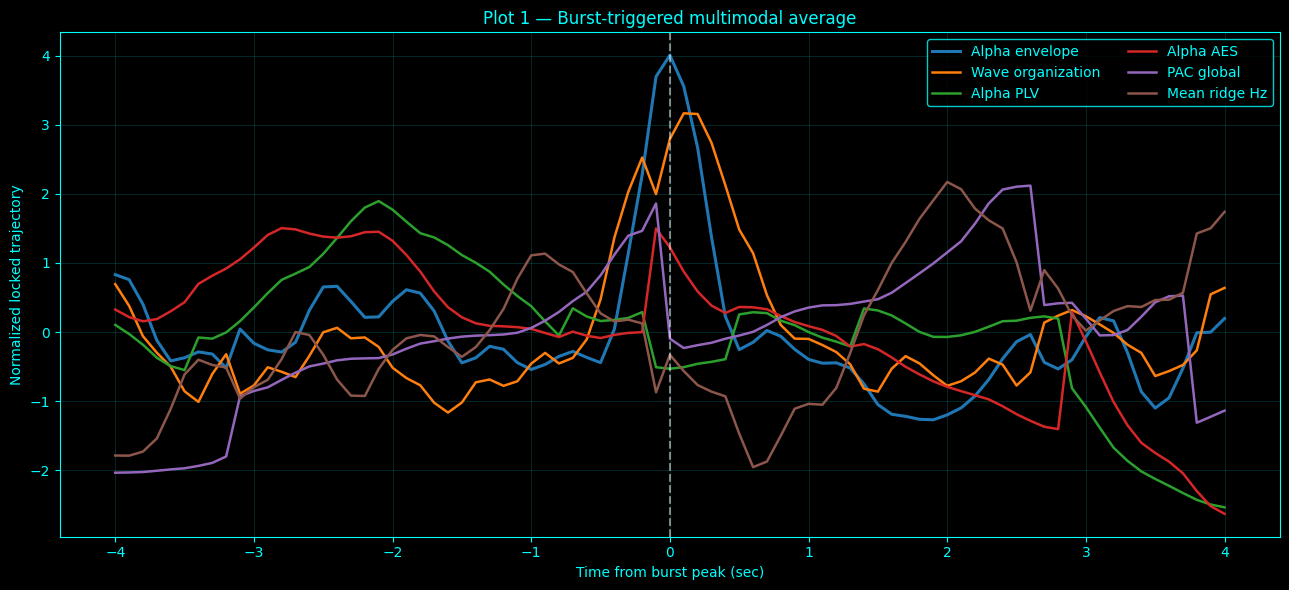

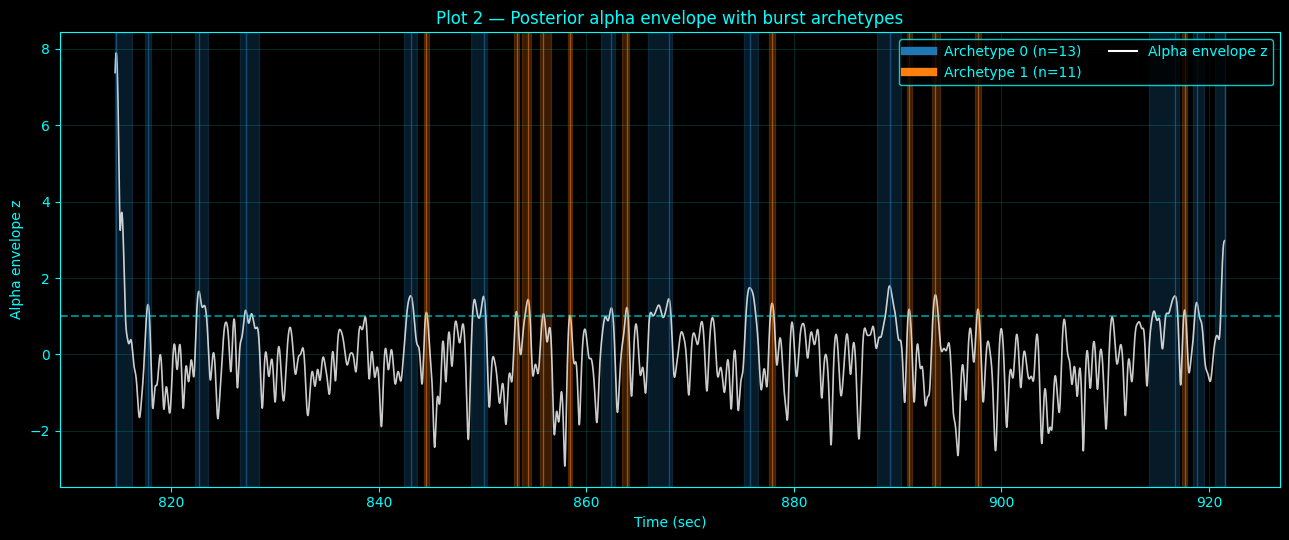

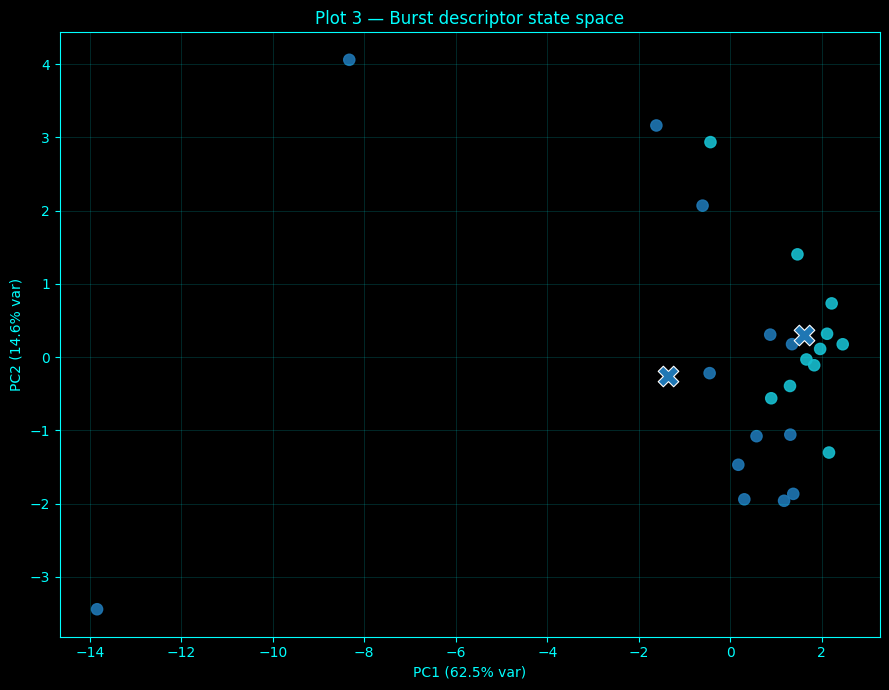

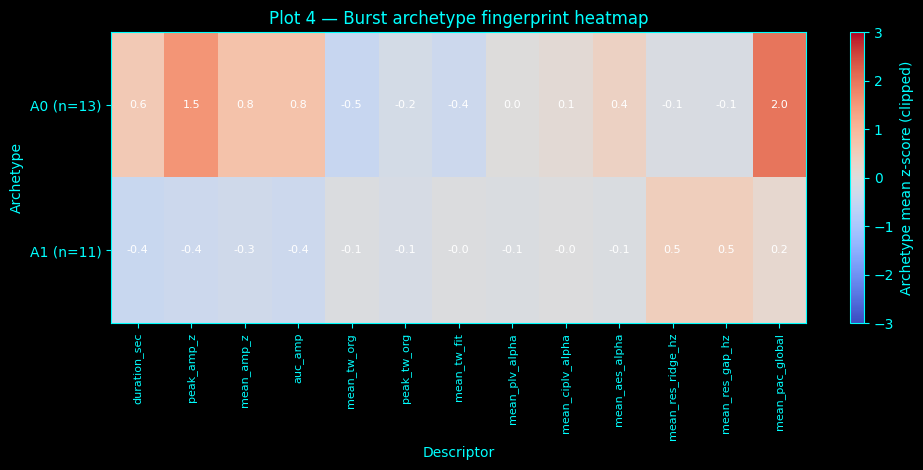

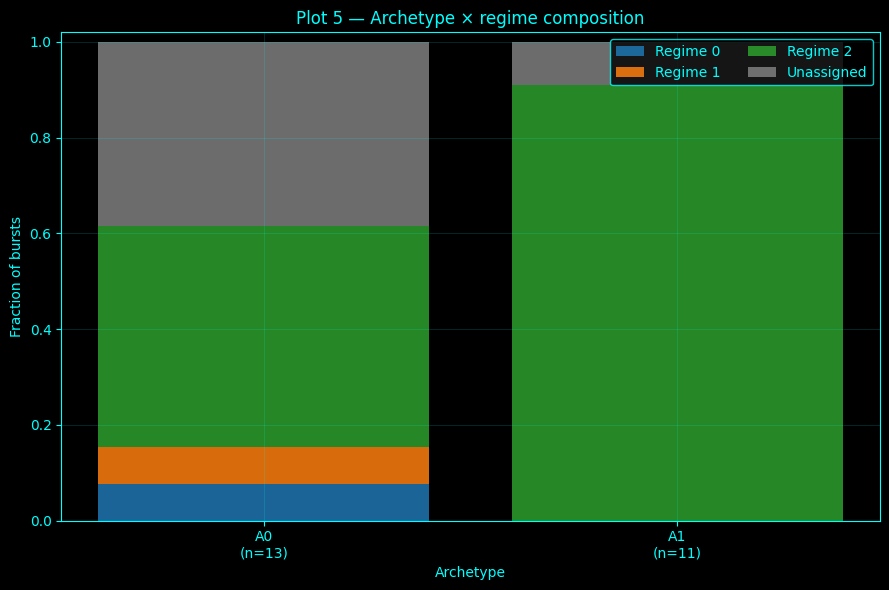

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot1_burst_triggered_multimodal_average.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot2_alpha_envelope_with_burst_archetypes.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot3_burst_descriptor_state_space.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot4_archetype_fingerprint_heatmap.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot5_archetype_regime_composition.png
Done.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.cluster.vq import kmeans2

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
results_dir = os.path.join(base_dir, "results")

out_dir = os.path.join(results_dir, "exploratory_alpha_burst_multimodal_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Candidate upstream outputs
traveling_wave_csv_candidates = [
    os.path.join(results_dir, "exploratory_alpha_traveling_wave_atlas", "traveling_wave_trajectory.csv"),
    "/mnt/data/traveling_wave_trajectory.csv",
]

plv_dict_candidates = [
    os.path.join(results_dir, "exploratory_phase_locking_value_atlas", "plv_output_dict.npy"),
]

aes_dict_candidates = [
    os.path.join(results_dir, "exploratory_amplitude_envelope_synchrony", "aes_output_dict.npy"),
]

resonance_npz_candidates = [
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
]

regime_traj_candidates = [
    os.path.join(results_dir, "exploratory_multimodal_regime_atlas", "multimodal_regime_trajectory.csv"),
]

# Segment config
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

# Alpha burst settings
alpha_search_band = (7.0, 13.0)
alpha_halfwidth_hz = 1.5
posterior_alpha_channels = ["P3", "Pz", "P4", "POz", "O1", "Oz", "O2"]

# Burst detection on posterior consensus alpha envelope
burst_high_z = 1.0
burst_low_z = 0.25
min_burst_duration_sec = 0.20
merge_gap_sec = 0.15

# Event-locking window around burst peak
lock_window_sec = (-4.0, 4.0)
lock_step_sec = 0.10

# Archetype clustering
candidate_k_values = [2, 3, 4, 5]
default_k_if_selection_fails = 3
fingerprint_clip_z = 3.0

# Plotting / style
ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def load_dict_npy(path):
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    try:
        return obj.item()
    except Exception:
        return obj

def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def lowpass_sos(cutoff_hz, fs, order=4):
    nyq = 0.5 * fs
    cutoff = min(cutoff_hz / nyq, 0.999)
    return signal.butter(order, cutoff, btype="lowpass", output="sos")

def compute_welch_psd(y, fs, window_sec=4.0, overlap=0.5, nfft=8192):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)
    f, pxx = signal.welch(
        y, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap,
        detrend="constant", scaling="density", nfft=nfft
    )
    return f, pxx

def robust_alpha_peak(freqs_hz, psd_1d, band=(7.0, 13.0)):
    mask = (freqs_hz >= band[0]) & (freqs_hz <= band[1]) & np.isfinite(psd_1d)
    if np.sum(mask) < 5:
        return np.nan
    f = freqs_hz[mask]
    y = psd_1d[mask]
    idx = int(np.nanargmax(y))
    return float(f[idx])

def linear_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)
    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)
    return np.interp(times_new, times_old[mask], values_old[mask], left=np.nan, right=np.nan)

def nearest_categorical_lookup(times_ref, values_ref, times_query, max_gap_sec=None):
    times_ref = np.asarray(times_ref, dtype=float)
    values_ref = np.asarray(values_ref)
    times_query = np.asarray(times_query, dtype=float)

    if len(times_ref) == 0:
        return np.full(len(times_query), np.nan)

    idx = np.searchsorted(times_ref, times_query, side="left")
    idx = np.clip(idx, 0, len(times_ref) - 1)

    left_idx = np.clip(idx - 1, 0, len(times_ref) - 1)
    right_idx = idx

    left_dist = np.abs(times_query - times_ref[left_idx])
    right_dist = np.abs(times_query - times_ref[right_idx])

    choose_left = left_dist <= right_dist
    nearest_idx = np.where(choose_left, left_idx, right_idx)

    out = values_ref[nearest_idx].astype(float)

    if max_gap_sec is not None:
        nearest_dist = np.minimum(left_dist, right_dist)
        out = np.where(nearest_dist <= max_gap_sec, out, np.nan)

    return out

def robust_scale_matrix(X):
    X = np.asarray(X, dtype=float)
    med = np.nanmedian(X, axis=0)
    q25 = np.nanpercentile(X, 25, axis=0)
    q75 = np.nanpercentile(X, 75, axis=0)
    iqr = q75 - q25
    sd = np.nanstd(X, axis=0)
    scale = np.where(iqr > 1e-8, iqr, np.where(sd > 1e-8, sd, 1.0))
    Z = (X - med) / scale
    return Z, med, scale

def fill_missing_columns(X):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        mask = np.isfinite(col)
        if np.sum(mask) == 0:
            continue
        if np.sum(mask) == 1:
            X[:, j] = col[mask][0]
            continue
        idx = np.arange(len(col))
        X[:, j] = np.interp(idx, idx[mask], col[mask])
    return X

def winsorize_columns(X, low=2, high=98):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        finite = np.isfinite(col)
        if np.sum(finite) < 3:
            continue
        lo = np.percentile(col[finite], low)
        hi = np.percentile(col[finite], high)
        X[finite, j] = np.clip(col[finite], lo, hi)
    return X

def pca_svd(X, n_components=5):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = U[:, :n_components] * S[:n_components]
    loadings = Vt[:n_components].T
    ev = (S ** 2) / max(X.shape[0] - 1, 1)
    evr = ev / (np.sum(ev) + eps)
    return scores, loadings, evr[:n_components]

def calinski_harabasz_score(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    n = len(labels)
    k = len(uniq)
    if k < 2 or k >= n:
        return np.nan

    overall_mean = np.mean(X, axis=0)
    B = 0.0
    W = 0.0
    for lab in uniq:
        Xi = X[labels == lab]
        if len(Xi) == 0:
            continue
        mean_i = np.mean(Xi, axis=0)
        B += len(Xi) * np.sum((mean_i - overall_mean) ** 2)
        W += np.sum((Xi - mean_i) ** 2)

    if W <= 0:
        return np.nan
    return (B / max(k - 1, 1)) / (W / max(n - k, 1))

def relabel_by_first_appearance(labels):
    labels = np.asarray(labels, dtype=int)
    order = []
    for x in labels:
        if x not in order:
            order.append(x)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels], dtype=int)

def choose_kmeans_labels(X, candidate_k_values, default_k, min_cluster_size=2):
    best_k = None
    best_labels = None
    best_score = -np.inf

    for k in candidate_k_values:
        if k < 2 or k >= len(X):
            continue
        try:
            _, labels = kmeans2(X, k, minit="points", iter=60)
            counts = np.bincount(labels, minlength=k)
            if np.min(counts) < min_cluster_size:
                continue
            score = calinski_harabasz_score(X, labels)
            if np.isfinite(score) and score > best_score:
                best_score = score
                best_k = k
                best_labels = labels.copy()
        except Exception:
            pass

    if best_labels is None:
        k = min(default_k, max(2, len(X) - 1))
        _, labels = kmeans2(X, k, minit="points", iter=60)
        best_k = k
        best_labels = labels.copy()
        best_score = calinski_harabasz_score(X, best_labels)

    return best_k, relabel_by_first_appearance(best_labels), best_score

def merge_small_clusters(X, labels, min_size=2):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels, dtype=int).copy()

    while True:
        uniq, counts = np.unique(labels, return_counts=True)
        if len(uniq) <= 1 or np.min(counts) >= min_size:
            break

        small_lab = uniq[np.argmin(counts)]
        large_labs = uniq[uniq != small_lab]

        cent_small = np.mean(X[labels == small_lab], axis=0)
        dists = []
        for lab in large_labs:
            cent_lab = np.mean(X[labels == lab], axis=0)
            dists.append(np.linalg.norm(cent_small - cent_lab))
        target_lab = large_labs[int(np.argmin(dists))]

        labels[labels == small_lab] = target_lab
        labels = relabel_by_first_appearance(labels)

    return labels

def mode_or_nan(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    vals, counts = np.unique(x.astype(int), return_counts=True)
    return float(vals[np.argmax(counts)])

def contiguous_runs(mask):
    mask = np.asarray(mask, dtype=bool)
    runs = []
    in_run = False
    start = None
    for i, v in enumerate(mask):
        if v and not in_run:
            start = i
            in_run = True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(mask) - 1))
    return runs

def detect_hysteresis_bursts(env_z, fs, high_z=1.0, low_z=0.25, min_duration_sec=0.2, merge_gap_sec=0.15):
    env_z = np.asarray(env_z, dtype=float)
    n = len(env_z)
    high_mask = env_z >= high_z
    burst_runs = []

    for h_start, h_end in contiguous_runs(high_mask):
        start = h_start
        while start > 0 and np.isfinite(env_z[start - 1]) and env_z[start - 1] >= low_z:
            start -= 1

        end = h_end
        while end < n - 1 and np.isfinite(env_z[end + 1]) and env_z[end + 1] >= low_z:
            end += 1

        burst_runs.append((start, end))

    if len(burst_runs) == 0:
        return []

    burst_runs = sorted(burst_runs, key=lambda x: x[0])
    merged = [burst_runs[0]]
    max_gap = int(round(merge_gap_sec * fs))

    for start, end in burst_runs[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end <= max_gap:
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))

    min_len = int(round(min_duration_sec * fs))
    merged = [(s, e) for s, e in merged if (e - s + 1) >= min_len]
    return merged

# -------------------------------------------------------
# LOAD RAW EEG AND BUILD POSTERIOR ALPHA CONSENSUS ENVELOPE
# -------------------------------------------------------
eeg = np.load(eeg_path, allow_pickle=True)
eeg = ensure_time_channel_layout(eeg, len(eeg_channel_names))

if end_index > eeg.shape[0]:
    raise ValueError("Requested segment exceeds data length.")

segment = eeg[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec = start_time + np.arange(n_samples) / fs_analysis

posterior_idx = [eeg_channel_names.index(ch) for ch in posterior_alpha_channels if ch in eeg_channel_names]
posterior_mean = np.nanmean(segment_ds[:, posterior_idx], axis=1)

freqs_hz, pxx = compute_welch_psd(posterior_mean, fs_analysis, window_sec=4.0, overlap=0.5, nfft=8192)
alpha_peak_hz = robust_alpha_peak(freqs_hz, pxx, band=alpha_search_band)
if not np.isfinite(alpha_peak_hz):
    alpha_peak_hz = 10.0

alpha_band = (
    max(alpha_search_band[0], alpha_peak_hz - alpha_halfwidth_hz),
    min(alpha_search_band[1], alpha_peak_hz + alpha_halfwidth_hz),
)

sos_alpha = bandpass_sos(alpha_band[0], alpha_band[1], fs_analysis, order=4)
sos_env = lowpass_sos(2.0, fs_analysis, order=4)

posterior_envs = []
for ch_i in posterior_idx:
    y = signal.sosfiltfilt(sos_alpha, segment_ds[:, ch_i])
    env = np.abs(signal.hilbert(y))
    env = signal.sosfiltfilt(sos_env, env)
    posterior_envs.append(env)

posterior_env = np.nanmean(np.vstack(posterior_envs), axis=0)
posterior_env_log = np.log10(posterior_env + eps)
posterior_env_z = (posterior_env_log - np.nanmean(posterior_env_log)) / (np.nanstd(posterior_env_log) + eps)

burst_runs = detect_hysteresis_bursts(
    posterior_env_z,
    fs=fs_analysis,
    high_z=burst_high_z,
    low_z=burst_low_z,
    min_duration_sec=min_burst_duration_sec,
    merge_gap_sec=merge_gap_sec,
)

if len(burst_runs) < 4:
    raise ValueError(
        f"Only found {len(burst_runs)} bursts. "
        "Try lowering burst_high_z or widening the alpha band if needed."
    )

# -------------------------------------------------------
# LOAD UPSTREAM MODALITIES
# -------------------------------------------------------
travel_path = first_existing(traveling_wave_csv_candidates)
plv_path = first_existing(plv_dict_candidates)
aes_path = first_existing(aes_dict_candidates)
res_path = first_existing(resonance_npz_candidates)
regime_path = first_existing(regime_traj_candidates)

tw_df = pd.read_csv(travel_path) if travel_path is not None else None
plv_dict = load_dict_npy(plv_path) if plv_path is not None else None
aes_dict = load_dict_npy(aes_path) if aes_path is not None else None
res_npz = np.load(res_path, allow_pickle=True) if res_path is not None else None
regime_df = pd.read_csv(regime_path) if regime_path is not None else None

# traveling-wave time series
if tw_df is not None:
    tw_time = tw_df["time_sec"].values.astype(float)
    tw_org = tw_df["organization_score_s"].values.astype(float)
    tw_fit = tw_df["fit_r2_s"].values.astype(float)
    tw_k = tw_df["wavenumber_rad_per_unit_s"].values.astype(float)
    tw_speed = tw_df["phase_velocity_units_per_sec_s"].values.astype(float)
else:
    tw_time = tw_org = tw_fit = tw_k = tw_speed = None

# PLV / ciPLV
if plv_dict is not None:
    plv_time = np.asarray(plv_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_plv = plv_dict.get("dynamic_global_plv_dict", {})
    dyn_ciplv = plv_dict.get("dynamic_global_ciplv_dict", {})
    plv_alpha = np.asarray(dyn_plv.get("alpha", np.full(len(plv_time), np.nan)), dtype=float)
    ciplv_alpha = np.asarray(dyn_ciplv.get("alpha", np.full(len(plv_time), np.nan)), dtype=float)
else:
    plv_time = plv_alpha = ciplv_alpha = None

# AES
if aes_dict is not None:
    aes_time = np.asarray(aes_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_aes = aes_dict.get("dynamic_global_dict", {})
    aes_alpha = np.asarray(dyn_aes.get("alpha", np.full(len(aes_time), np.nan)), dtype=float)
else:
    aes_time = aes_alpha = None

# resonance / PAC
if res_npz is not None:
    res_time = np.asarray(res_npz["common_time_sec_abs"], dtype=float)
    wavelet_ridge = np.asarray(res_npz["wavelet_ridge_hz"], dtype=float)
    stft_ridge = np.asarray(res_npz["stft_ridge_hz"], dtype=float)
    dynamic_pac = np.asarray(res_npz["dynamic_pac_matrix"], dtype=float)

    res_ridge_mean = np.nanmean(wavelet_ridge, axis=1)
    res_ridge_gap = np.nanmean(np.abs(wavelet_ridge - stft_ridge), axis=1)
    res_pac_global = np.nanmean(dynamic_pac, axis=1)
else:
    res_time = res_ridge_mean = res_ridge_gap = res_pac_global = None

# regime
if regime_df is not None:
    regime_time = regime_df["time_sec"].values.astype(float)
    if "regime_clean" in regime_df.columns:
        regime_clean = regime_df["regime_clean"].values.astype(float)
    elif "regime" in regime_df.columns:
        regime_clean = regime_df["regime"].values.astype(float)
    else:
        regime_clean = None
else:
    regime_time = regime_clean = None

# -------------------------------------------------------
# BURST-LOCKED MULTIMODAL EXTRACTION
# -------------------------------------------------------
lock_rel_time = np.arange(lock_window_sec[0], lock_window_sec[1] + lock_step_sec / 2, lock_step_sec)
n_lock = len(lock_rel_time)

burst_rows = []
locked = {
    "alpha_env_z": [],
    "tw_org": [],
    "tw_fit": [],
    "tw_k": [],
    "tw_speed": [],
    "plv_alpha": [],
    "ciplv_alpha": [],
    "aes_alpha": [],
    "res_ridge_mean": [],
    "res_ridge_gap": [],
    "res_pac_global": [],
}

for b_i, (s, e) in enumerate(burst_runs):
    burst_time = time_sec[s:e+1]
    burst_env = posterior_env_z[s:e+1]

    peak_rel_idx = int(np.nanargmax(burst_env))
    peak_idx = s + peak_rel_idx
    peak_time = time_sec[peak_idx]
    lock_abs_time = peak_time + lock_rel_time

    locked["alpha_env_z"].append(linear_interp(time_sec, posterior_env_z, lock_abs_time))

    if tw_time is not None:
        locked["tw_org"].append(linear_interp(tw_time, tw_org, lock_abs_time))
        locked["tw_fit"].append(linear_interp(tw_time, tw_fit, lock_abs_time))
        locked["tw_k"].append(linear_interp(tw_time, tw_k, lock_abs_time))
        locked["tw_speed"].append(linear_interp(tw_time, tw_speed, lock_abs_time))
    else:
        for k in ["tw_org", "tw_fit", "tw_k", "tw_speed"]:
            locked[k].append(np.full(n_lock, np.nan))

    if plv_time is not None:
        locked["plv_alpha"].append(linear_interp(plv_time, plv_alpha, lock_abs_time))
        locked["ciplv_alpha"].append(linear_interp(plv_time, ciplv_alpha, lock_abs_time))
    else:
        locked["plv_alpha"].append(np.full(n_lock, np.nan))
        locked["ciplv_alpha"].append(np.full(n_lock, np.nan))

    if aes_time is not None:
        locked["aes_alpha"].append(linear_interp(aes_time, aes_alpha, lock_abs_time))
    else:
        locked["aes_alpha"].append(np.full(n_lock, np.nan))

    if res_time is not None:
        locked["res_ridge_mean"].append(linear_interp(res_time, res_ridge_mean, lock_abs_time))
        locked["res_ridge_gap"].append(linear_interp(res_time, res_ridge_gap, lock_abs_time))
        locked["res_pac_global"].append(linear_interp(res_time, res_pac_global, lock_abs_time))
    else:
        locked["res_ridge_mean"].append(np.full(n_lock, np.nan))
        locked["res_ridge_gap"].append(np.full(n_lock, np.nan))
        locked["res_pac_global"].append(np.full(n_lock, np.nan))

    # FIX: categorical regime lookup with nearest-neighbor, not linear interpolation
    if regime_time is not None and regime_clean is not None:
        regime_vals_burst = nearest_categorical_lookup(
            regime_time,
            regime_clean,
            burst_time,
            max_gap_sec=0.50
        )
        regime_vals_peak = nearest_categorical_lookup(
            regime_time,
            regime_clean,
            np.array([peak_time]),
            max_gap_sec=0.50
        )
        regime_at_burst = mode_or_nan(regime_vals_burst)
        regime_at_peak = mode_or_nan(regime_vals_peak)
    else:
        regime_at_burst = np.nan
        regime_at_peak = np.nan

    duration_sec = len(burst_time) / fs_analysis
    peak_amp_z = float(np.nanmax(burst_env))
    mean_amp_z = float(np.nanmean(burst_env))
    auc_amp = float(np.trapz(np.maximum(burst_env, 0.0), dx=1.0 / fs_analysis))

    mean_tw_org = float(np.nanmean(linear_interp(tw_time, tw_org, burst_time))) if tw_time is not None else np.nan
    peak_tw_org = float(np.nanmax(linear_interp(tw_time, tw_org, burst_time))) if tw_time is not None else np.nan
    mean_tw_fit = float(np.nanmean(linear_interp(tw_time, tw_fit, burst_time))) if tw_time is not None else np.nan

    mean_plv_alpha = float(np.nanmean(linear_interp(plv_time, plv_alpha, burst_time))) if plv_time is not None else np.nan
    mean_ciplv_alpha = float(np.nanmean(linear_interp(plv_time, ciplv_alpha, burst_time))) if plv_time is not None else np.nan
    mean_aes_alpha = float(np.nanmean(linear_interp(aes_time, aes_alpha, burst_time))) if aes_time is not None else np.nan

    mean_res_ridge = float(np.nanmean(linear_interp(res_time, res_ridge_mean, burst_time))) if res_time is not None else np.nan
    mean_res_gap = float(np.nanmean(linear_interp(res_time, res_ridge_gap, burst_time))) if res_time is not None else np.nan
    mean_pac = float(np.nanmean(linear_interp(res_time, res_pac_global, burst_time))) if res_time is not None else np.nan

    burst_rows.append({
        "burst_index": b_i,
        "start_time_sec": float(time_sec[s]),
        "end_time_sec": float(time_sec[e]),
        "peak_time_sec": float(peak_time),
        "duration_sec": float(duration_sec),
        "peak_amp_z": peak_amp_z,
        "mean_amp_z": mean_amp_z,
        "auc_amp": auc_amp,
        "mean_tw_org": mean_tw_org,
        "peak_tw_org": peak_tw_org,
        "mean_tw_fit": mean_tw_fit,
        "mean_plv_alpha": mean_plv_alpha,
        "mean_ciplv_alpha": mean_ciplv_alpha,
        "mean_aes_alpha": mean_aes_alpha,
        "mean_res_ridge_hz": mean_res_ridge,
        "mean_res_gap_hz": mean_res_gap,
        "mean_pac_global": mean_pac,
        "regime_mode_during_burst": regime_at_burst,
        "regime_mode_at_peak": regime_at_peak,
    })

burst_df = pd.DataFrame(burst_rows)

for k in locked.keys():
    locked[k] = np.asarray(locked[k], dtype=float)

# -------------------------------------------------------
# BURST ARCHETYPES
# -------------------------------------------------------
descriptor_cols = [
    "duration_sec",
    "peak_amp_z",
    "mean_amp_z",
    "auc_amp",
    "mean_tw_org",
    "peak_tw_org",
    "mean_tw_fit",
    "mean_plv_alpha",
    "mean_ciplv_alpha",
    "mean_aes_alpha",
    "mean_res_ridge_hz",
    "mean_res_gap_hz",
    "mean_pac_global",
]

descriptor_df = burst_df[descriptor_cols].copy()
valid_frac = descriptor_df.notna().mean(axis=0)
descriptor_cols = [c for c in descriptor_cols if valid_frac[c] >= 0.50]

X_desc = descriptor_df[descriptor_cols].values.astype(float)
X_desc = fill_missing_columns(X_desc)

# robustify before clustering
X_desc = winsorize_columns(X_desc, low=2, high=98)

X_desc_z, desc_med, desc_scale = robust_scale_matrix(X_desc)

min_bursts_per_archetype = max(3, int(np.ceil(0.08 * len(X_desc_z))))

if len(X_desc_z) >= 4:
    k_arch, labels_arch, ch_score = choose_kmeans_labels(
        X_desc_z,
        candidate_k_values=candidate_k_values,
        default_k=default_k_if_selection_fails,
        min_cluster_size=min_bursts_per_archetype,
    )
    labels_arch = merge_small_clusters(X_desc_z, labels_arch, min_size=min_bursts_per_archetype)
    labels_arch = relabel_by_first_appearance(labels_arch)
else:
    k_arch = 1
    labels_arch = np.zeros(len(X_desc_z), dtype=int)
    ch_score = np.nan

burst_df["archetype"] = labels_arch

scores_burst, loadings_burst, evr_burst = pca_svd(
    X_desc_z,
    n_components=min(5, X_desc_z.shape[1], X_desc_z.shape[0])
)

n_arch = len(np.unique(labels_arch))
arch_counts = np.array([np.sum(labels_arch == a) for a in range(n_arch)], dtype=int)

arch_fingerprint = np.vstack([
    np.nanmean(X_desc_z[labels_arch == a, :], axis=0)
    for a in range(n_arch)
])

# display-clipped fingerprint only for plotting
arch_fingerprint_display = np.clip(arch_fingerprint, -fingerprint_clip_z, fingerprint_clip_z)

# archetype-locked averages
arch_locked = {}
for key, arr in locked.items():
    arch_locked[key] = []
    for a in range(n_arch):
        m = labels_arch == a
        if np.sum(m) == 0:
            arch_locked[key].append(np.full(arr.shape[1], np.nan))
        else:
            arch_locked[key].append(np.nanmean(arr[m], axis=0))
    arch_locked[key] = np.asarray(arch_locked[key], dtype=float)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
burst_csv_path = os.path.join(out_dir, "alpha_burst_summary.csv")
descriptor_csv_path = os.path.join(out_dir, "alpha_burst_descriptors_used.csv")
trajectory_npz_path = os.path.join(out_dir, "alpha_burst_locked_trajectories.npz")
notes_txt_path = os.path.join(out_dir, "alpha_burst_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_burst_triggered_multimodal_average.png")
plot2_path = os.path.join(plots_dir, "plot2_alpha_envelope_with_burst_archetypes.png")
plot3_path = os.path.join(plots_dir, "plot3_burst_descriptor_state_space.png")
plot4_path = os.path.join(plots_dir, "plot4_archetype_fingerprint_heatmap.png")
plot5_path = os.path.join(plots_dir, "plot5_archetype_regime_composition.png")

burst_df.to_csv(burst_csv_path, index=False)

pd.DataFrame({
    "descriptor": descriptor_cols,
    "median": desc_med[:len(descriptor_cols)],
    "scale": desc_scale[:len(descriptor_cols)],
    "pc1_loading": loadings_burst[:, 0] if scores_burst.shape[1] >= 1 else np.nan,
    "pc2_loading": loadings_burst[:, 1] if scores_burst.shape[1] >= 2 else np.nan,
}).to_csv(descriptor_csv_path, index=False)

np.savez_compressed(
    trajectory_npz_path,
    lock_rel_time=lock_rel_time,
    alpha_peak_hz=alpha_peak_hz,
    alpha_band=np.array(alpha_band, dtype=float),
    descriptor_cols=np.array(descriptor_cols, dtype=object),
    burst_labels=labels_arch,
    scores_burst=scores_burst,
    arch_counts=arch_counts,
    arch_fingerprint=arch_fingerprint,
    arch_fingerprint_display=arch_fingerprint_display,
    **{f"locked_{k}": v for k, v in locked.items()},
    **{f"arch_locked_{k}": v for k, v in arch_locked.items()},
)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory alpha burst multimodal atlas\n")
    f.write("=======================================\n\n")
    f.write("Key fixes in this version:\n")
    f.write("1. Regime labels are categorical and are now matched by nearest-neighbor lookup, not linear interpolation.\n")
    f.write("2. Descriptor clustering is winsorized before scaling to reduce outlier-driven archetypes.\n")
    f.write("3. Tiny archetypes are prevented / merged using a minimum cluster size rule.\n")
    f.write("4. Fingerprint heatmap display is clipped for readability without altering saved raw values.\n")
    f.write("5. Plot 5 includes explicit unassigned fractions if regime mapping is unavailable.\n\n")
    f.write(f"Posterior alpha peak: {alpha_peak_hz:.3f} Hz\n")
    f.write(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz\n")
    f.write(f"Bursts found: {len(burst_df)}\n")
    f.write(f"Selected archetypes: {n_arch}\n")
    f.write(f"Minimum bursts per archetype: {min_bursts_per_archetype}\n")
    f.write(f"CH score: {ch_score}\n")
    for a in range(n_arch):
        f.write(f"  Archetype {a}: {arch_counts[a]} bursts\n")

print(f"Posterior alpha peak: {alpha_peak_hz:.3f} Hz")
print(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz")
print(f"Bursts found: {len(burst_df)}")
print(f"Selected archetypes: {n_arch}")
print(f"Minimum bursts per archetype: {min_bursts_per_archetype}")
for a in range(n_arch):
    print(f"  Archetype {a}: {arch_counts[a]} bursts")
print(f"Saved burst CSV: {burst_csv_path}")
print(f"Saved descriptor CSV: {descriptor_csv_path}")
print(f"Saved locked NPZ: {trajectory_npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — BURST-TRIGGERED MULTIMODAL AVERAGE
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax1)

def norm_for_plot(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x) + eps
    return (x - mu) / sd

avg_alpha = np.nanmean(locked["alpha_env_z"], axis=0)
ax1.plot(lock_rel_time, norm_for_plot(avg_alpha), linewidth=2.2, label="Alpha envelope")

if np.any(np.isfinite(locked["tw_org"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["tw_org"], axis=0)), linewidth=1.8, label="Wave organization")

if np.any(np.isfinite(locked["plv_alpha"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["plv_alpha"], axis=0)), linewidth=1.8, label="Alpha PLV")

if np.any(np.isfinite(locked["aes_alpha"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["aes_alpha"], axis=0)), linewidth=1.8, label="Alpha AES")

if np.any(np.isfinite(locked["res_pac_global"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["res_pac_global"], axis=0)), linewidth=1.8, label="PAC global")

if np.any(np.isfinite(locked["res_ridge_mean"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["res_ridge_mean"], axis=0)), linewidth=1.8, label="Mean ridge Hz")

ax1.axvline(0.0, color="white", linestyle="--", alpha=0.5)
ax1.set_title("Plot 1 — Burst-triggered multimodal average")
ax1.set_xlabel("Time from burst peak (sec)")
ax1.set_ylabel("Normalized locked trajectory")
ax1.legend(loc="upper right", ncol=2)

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ALPHA ENVELOPE WITH BURST ARCHETYPES
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(13, 5.5), facecolor=BG)
style_ax(ax2)

ax2.plot(time_sec, posterior_env_z, linewidth=1.2, color="white", alpha=0.8, label="Posterior alpha envelope z")
ax2.axhline(burst_high_z, color=ACCENT, linestyle="--", alpha=0.5, label="High threshold")

cmap = plt.cm.tab10
for _, row in burst_df.iterrows():
    a = int(row["archetype"])
    ax2.axvspan(row["start_time_sec"], row["end_time_sec"], color=cmap(a), alpha=0.22)
    ax2.axvline(row["peak_time_sec"], color=cmap(a), alpha=0.55, linewidth=1.0)

ax2.set_title("Plot 2 — Posterior alpha envelope with burst archetypes")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Alpha envelope z")

legend_handles = []
legend_labels = []
for a in range(n_arch):
    legend_handles.append(plt.Line2D([0], [0], color=cmap(a), linewidth=6))
    legend_labels.append(f"Archetype {a} (n={arch_counts[a]})")
legend_handles.append(plt.Line2D([0], [0], color="white", linewidth=1.5))
legend_labels.append("Alpha envelope z")
ax2.legend(legend_handles, legend_labels, loc="upper right", ncol=2)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — BURST DESCRIPTOR STATE SPACE
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax3)

if scores_burst.shape[1] >= 2:
    ax3.scatter(
        scores_burst[:, 0],
        scores_burst[:, 1],
        c=labels_arch,
        cmap="tab10",
        s=65,
        alpha=0.9,
    )
    for a in range(n_arch):
        m = labels_arch == a
        ax3.scatter(
            np.mean(scores_burst[m, 0]),
            np.mean(scores_burst[m, 1]),
            c=[a],
            cmap="tab10",
            s=220,
            marker="X",
            edgecolors="white",
            linewidths=0.8,
        )
    ax3.set_xlabel(f"PC1 ({100*evr_burst[0]:.1f}% var)")
    ax3.set_ylabel(f"PC2 ({100*evr_burst[1]:.1f}% var)")
else:
    ax3.scatter(np.arange(len(scores_burst)), scores_burst[:, 0], c=labels_arch, cmap="tab10", s=65, alpha=0.9)
    ax3.set_xlabel("Burst index")
    ax3.set_ylabel("PC1")

ax3.set_title("Plot 3 — Burst descriptor state space")

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — ARCHETYPE FINGERPRINT HEATMAP
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(max(10, 0.55 * len(descriptor_cols)), 4.8), facecolor=BG)
style_ax(ax4, heatmap=True)

im4 = ax4.imshow(
    arch_fingerprint_display,
    cmap="coolwarm",
    aspect="auto",
    interpolation="nearest",
    vmin=-fingerprint_clip_z,
    vmax=fingerprint_clip_z,
)

ax4.set_title("Plot 4 — Burst archetype fingerprint heatmap")
ax4.set_xlabel("Descriptor")
ax4.set_ylabel("Archetype")
ax4.set_xticks(np.arange(len(descriptor_cols)))
ax4.set_xticklabels(descriptor_cols, rotation=90, fontsize=8)
ax4.set_yticks(np.arange(n_arch))
ax4.set_yticklabels([f"A{a} (n={arch_counts[a]})" for a in range(n_arch)])

# annotate cells for readability
for i in range(n_arch):
    for j in range(len(descriptor_cols)):
        ax4.text(
            j, i,
            f"{arch_fingerprint_display[i, j]:.1f}",
            ha="center", va="center",
            fontsize=8,
            color="white"
        )

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label("Archetype mean z-score (clipped)", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — ARCHETYPE × REGIME COMPOSITION
# -------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax5)

regime_vals = burst_df["regime_mode_at_peak"].values.astype(float)
has_any_regime = np.any(np.isfinite(regime_vals))

if has_any_regime:
    regimes = np.sort(pd.Series(regime_vals[np.isfinite(regime_vals)].astype(int)).unique())
    bottoms = np.zeros(n_arch, dtype=float)

    for r in regimes:
        vals = []
        for a in range(n_arch):
            sub = burst_df[burst_df["archetype"] == a]
            total = len(sub)
            if total == 0:
                vals.append(0.0)
            else:
                vals.append(np.sum(sub["regime_mode_at_peak"].values == r) / total)
        vals = np.asarray(vals, dtype=float)

        ax5.bar(
            np.arange(n_arch),
            vals,
            bottom=bottoms,
            label=f"Regime {int(r)}",
            alpha=0.85,
        )
        bottoms += vals

    # explicit unassigned fraction
    unknown_vals = []
    for a in range(n_arch):
        sub = burst_df[burst_df["archetype"] == a]
        total = len(sub)
        if total == 0:
            unknown_vals.append(0.0)
        else:
            unknown_vals.append(np.mean(~np.isfinite(sub["regime_mode_at_peak"].values)))
    unknown_vals = np.asarray(unknown_vals, dtype=float)

    if np.any(unknown_vals > 0):
        ax5.bar(
            np.arange(n_arch),
            unknown_vals,
            bottom=bottoms,
            color="gray",
            alpha=0.85,
            label="Unassigned"
        )
        bottoms += unknown_vals

    ax5.set_title("Plot 5 — Archetype × regime composition")
    ax5.set_xlabel("Archetype")
    ax5.set_ylabel("Fraction of bursts")
    ax5.set_xticks(np.arange(n_arch))
    ax5.set_xticklabels([f"A{a}\n(n={arch_counts[a]})" for a in range(n_arch)])
    ax5.set_ylim(0, 1.02)
    ax5.legend(loc="upper right", ncol=2)
else:
    counts = np.array([np.sum(labels_arch == a) for a in range(n_arch)], dtype=float)
    mean_durs = np.array([np.nanmean(burst_df.loc[labels_arch == a, "duration_sec"]) for a in range(n_arch)], dtype=float)

    ax5.bar(np.arange(n_arch) - 0.18, counts, width=0.36, label="Burst count", alpha=0.85)
    ax5.bar(np.arange(n_arch) + 0.18, mean_durs, width=0.36, label="Mean duration (sec)", alpha=0.85)

    ax5.set_title("Plot 5 — Archetype abundance and duration")
    ax5.set_xlabel("Archetype")
    ax5.set_ylabel("Value")
    ax5.set_xticks(np.arange(n_arch))
    ax5.set_xticklabels([f"A{a}\n(n={arch_counts[a]})" for a in range(n_arch)])
    ax5.legend(loc="upper right")

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

Loaded RQA: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_recurrence_windowed_metrics.csv
Loaded state cloud: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_cycle_state_recurrence_density.csv
Loaded burst-locked NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_recurrence_burst_locked.npz


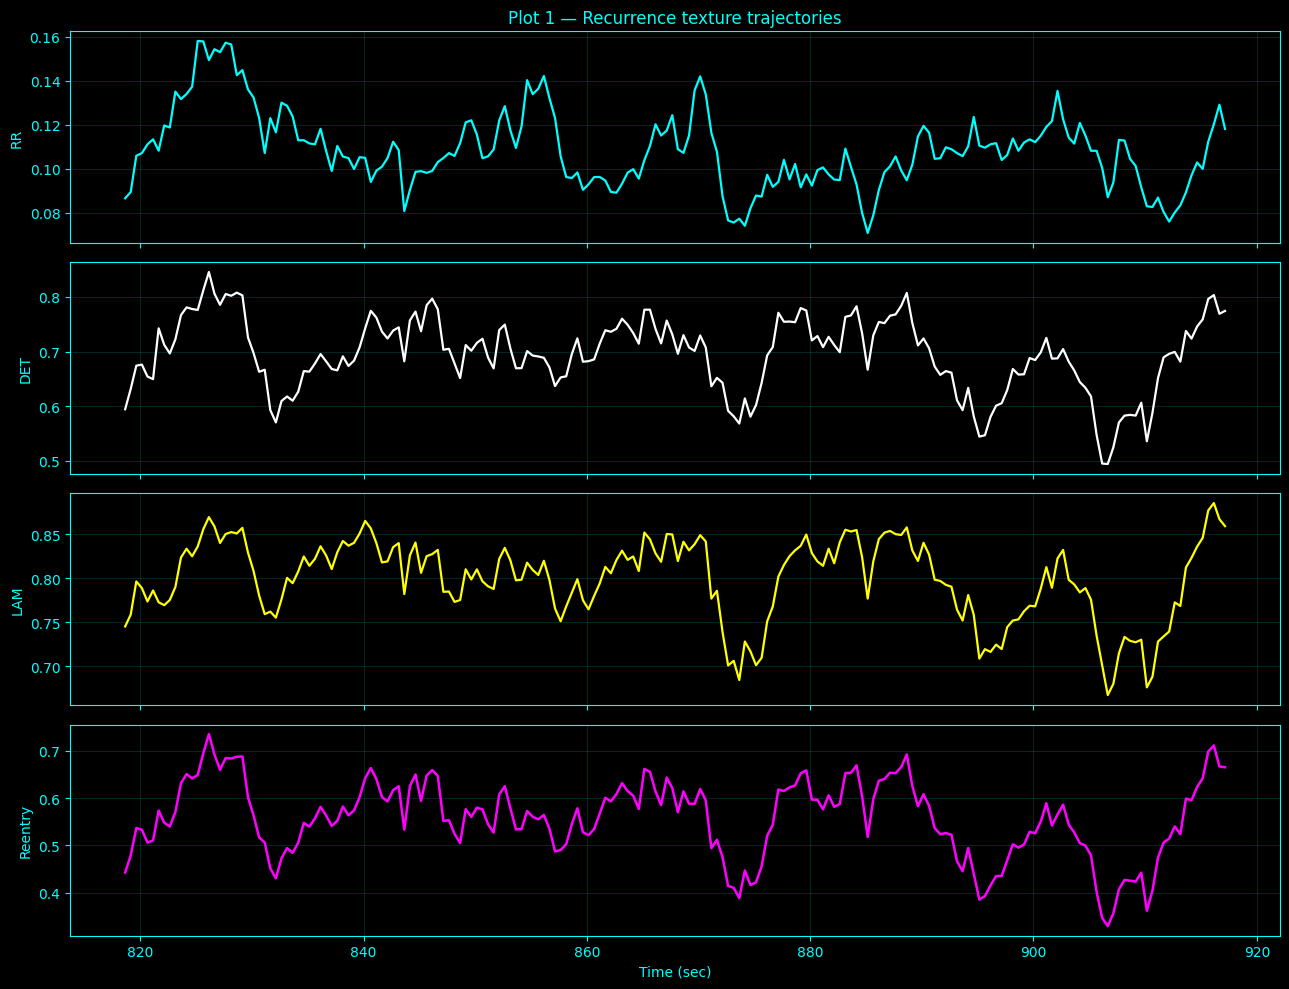

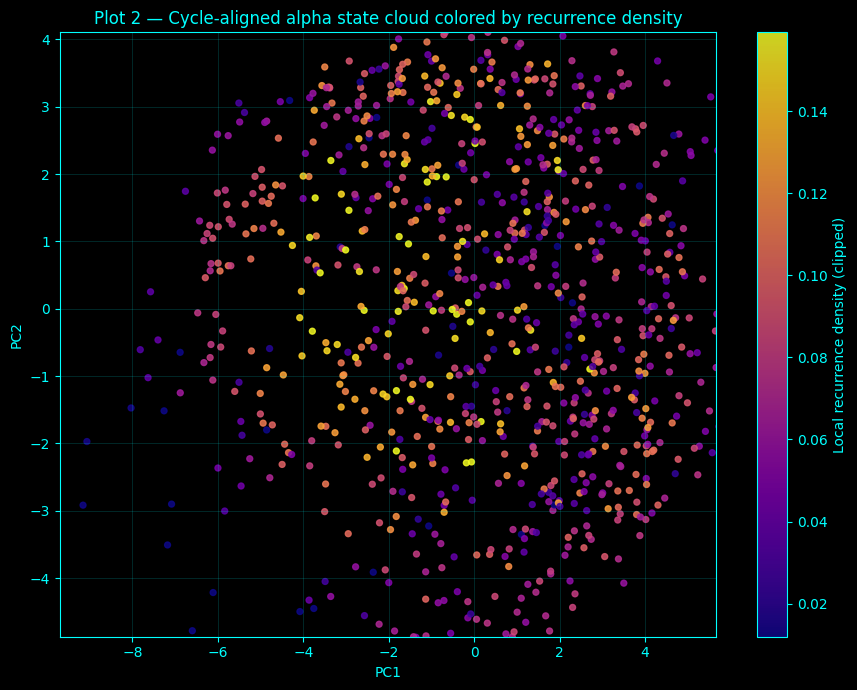

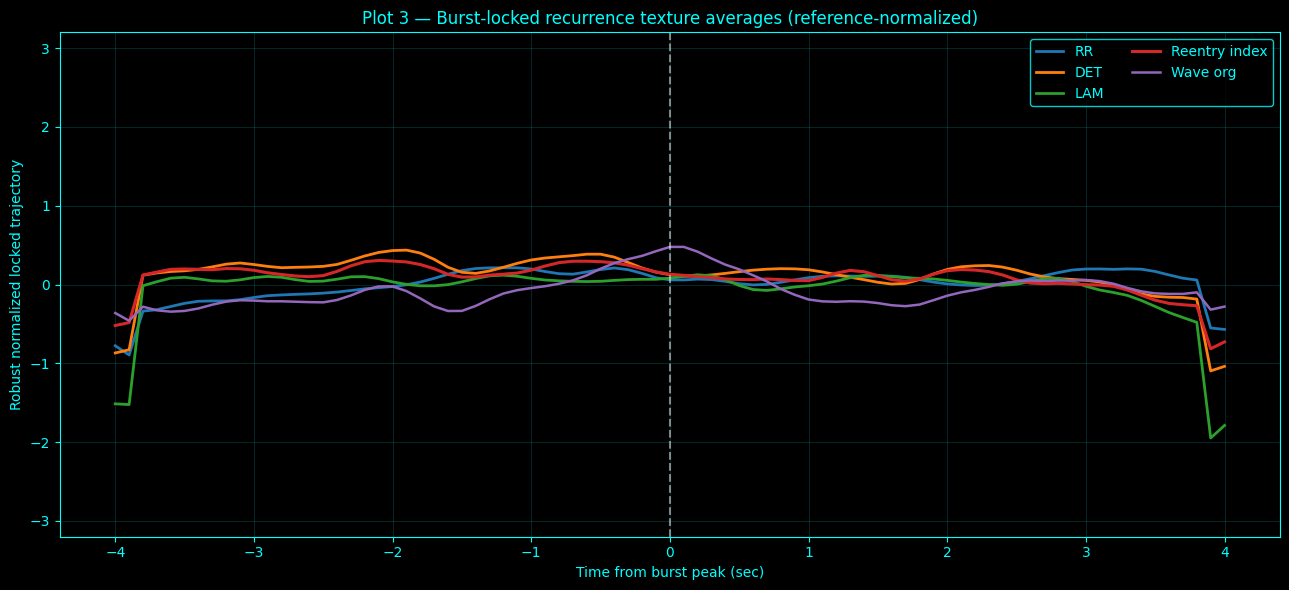

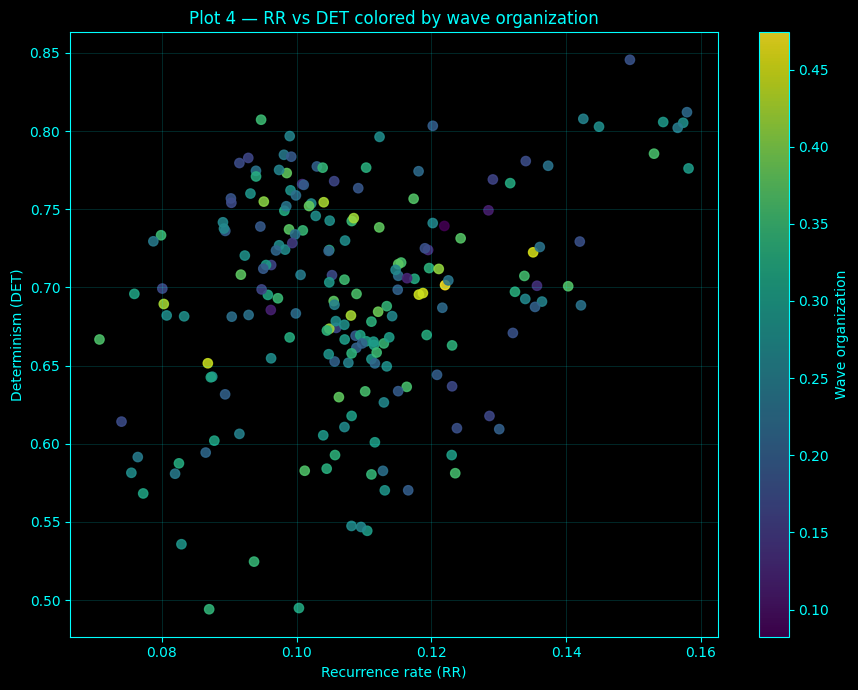

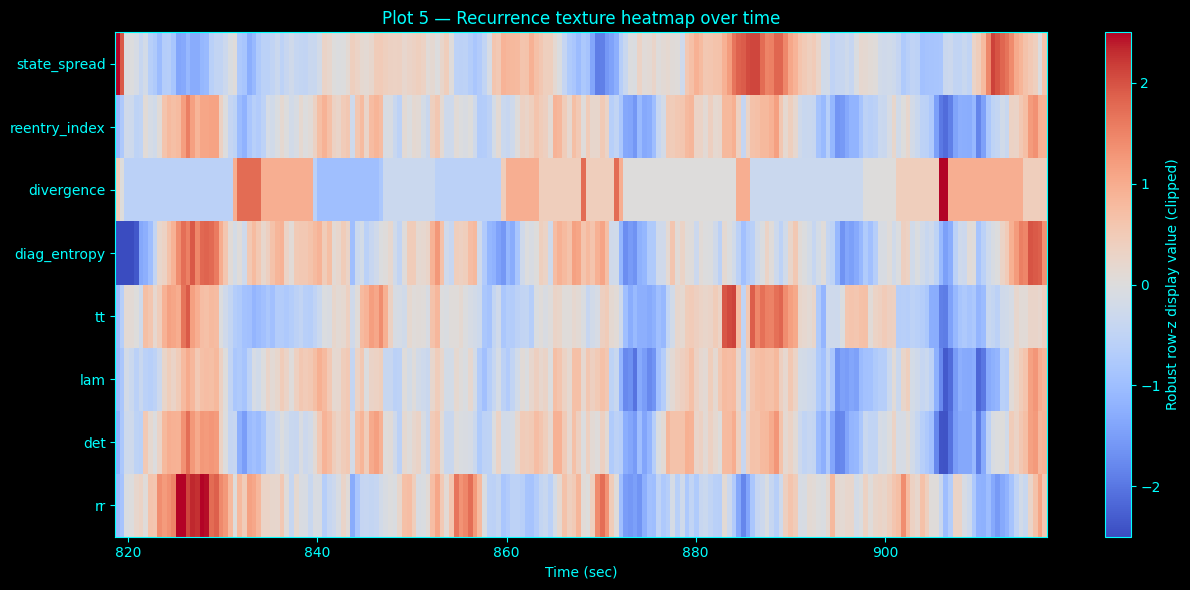

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot1_recurrence_metric_trajectories.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot2_state_cloud_recurrence_density.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot3_burst_locked_recurrence_averages_FIXED.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot4_rr_vs_det_colored_by_wave_org.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot5_recurrence_metric_heatmap_over_time.png
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results")

candidate_dirs = [
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2"),
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED"),
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_FIXED"),
]

# fallback to uploaded files if needed
fallback_rqa_csv = "/mnt/data/alpha_recurrence_windowed_metrics.csv"
fallback_state_csv = "/mnt/data/alpha_cycle_state_recurrence_density.csv"
fallback_locked_npz = "/mnt/data/alpha_recurrence_burst_locked.npz"

plot_out_dir = None
rqa_csv_path = None
state_csv_path = None
locked_npz_path = None

for d in candidate_dirs:
    a = os.path.join(d, "alpha_recurrence_windowed_metrics.csv")
    b = os.path.join(d, "alpha_cycle_state_recurrence_density.csv")
    c = os.path.join(d, "alpha_recurrence_burst_locked.npz")
    if os.path.exists(a) and os.path.exists(b) and os.path.exists(c):
        rqa_csv_path = a
        state_csv_path = b
        locked_npz_path = c
        plot_out_dir = os.path.join(d, "plots_rebuilt")
        break

if rqa_csv_path is None:
    rqa_csv_path = fallback_rqa_csv
    state_csv_path = fallback_state_csv
    locked_npz_path = fallback_locked_npz
    plot_out_dir = "/mnt/data/recurrence_plots_rebuilt"

os.makedirs(plot_out_dir, exist_ok=True)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

def smooth_1d_nanaware(x, win=3):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x.copy()

    out = x.copy()
    finite = np.isfinite(x)
    if np.sum(finite) < 3:
        return out

    idx = np.arange(len(x))
    filled = np.interp(idx, idx[finite], x[finite])
    kernel = np.ones(win, dtype=float) / win
    smoothed = np.convolve(filled, kernel, mode="same")
    out[finite] = smoothed[finite]
    return out

def robust_row_z(row, clip=2.5):
    row = np.asarray(row, dtype=float)
    med = np.nanmedian(row)
    q25 = np.nanpercentile(row, 25)
    q75 = np.nanpercentile(row, 75)
    scale = (q75 - q25) if (q75 - q25) > 1e-8 else (np.nanstd(row) + eps)
    z = (row - med) / scale
    return np.clip(z, -clip, clip)

def normalize_locked_against_reference(center_curve, reference_series, support_frac=None,
                                       min_support=0.40, clip=3.0, smooth_win=3):
    """
    Key fix:
    normalize the burst-locked center curve against the full RQA trajectory
    for the same metric, not against the locked curve itself.
    """
    center_curve = np.asarray(center_curve, dtype=float).copy()
    ref = np.asarray(reference_series, dtype=float)

    finite_ref = np.isfinite(ref)
    if np.sum(finite_ref) < 5:
        return np.full_like(center_curve, np.nan)

    med = np.nanmedian(ref)
    q25 = np.nanpercentile(ref, 25)
    q75 = np.nanpercentile(ref, 75)
    scale = (q75 - q25) if (q75 - q25) > 1e-8 else (np.nanstd(ref) + eps)

    y = (center_curve - med) / scale

    if support_frac is not None:
        support_frac = np.asarray(support_frac, dtype=float)
        y[support_frac < min_support] = np.nan

    y = smooth_1d_nanaware(y, win=smooth_win)

    if support_frac is not None:
        y[support_frac < min_support] = np.nan

    return np.clip(y, -clip, clip)

def center_and_mask_locked(arr, stat="median", min_fraction=0.40, smooth_win=3):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[0] == 0:
        n = arr.shape[1] if arr.ndim == 2 else 0
        return np.full(n, np.nan), np.zeros(n)

    support = np.sum(np.isfinite(arr), axis=0).astype(float)
    max_support = np.nanmax(support) if len(support) > 0 else 0.0
    needed = max(1, int(np.ceil(min_fraction * max_support))) if max_support > 0 else 1

    if stat == "median":
        center = np.nanmedian(arr, axis=0)
    else:
        center = np.nanmean(arr, axis=0)

    center[support < needed] = np.nan
    center = smooth_1d_nanaware(center, win=smooth_win)
    center[support < needed] = np.nan

    support_frac = support / (max_support + eps) if max_support > 0 else np.zeros_like(support)
    return center, support_frac

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
rqa_df = pd.read_csv(rqa_csv_path)
state_df = pd.read_csv(state_csv_path)
locked_npz = np.load(locked_npz_path, allow_pickle=True)

print(f"Loaded RQA: {rqa_csv_path}")
print(f"Loaded state cloud: {state_csv_path}")
print(f"Loaded burst-locked NPZ: {locked_npz_path}")

# -------------------------------------------------------
# PLOT PATHS
# -------------------------------------------------------
plot1_path = os.path.join(plot_out_dir, "plot1_recurrence_metric_trajectories.png")
plot2_path = os.path.join(plot_out_dir, "plot2_state_cloud_recurrence_density.png")
plot3_path = os.path.join(plot_out_dir, "plot3_burst_locked_recurrence_averages_FIXED.png")
plot4_path = os.path.join(plot_out_dir, "plot4_rr_vs_det_colored_by_wave_org.png")
plot5_path = os.path.join(plot_out_dir, "plot5_recurrence_metric_heatmap_over_time.png")

# -------------------------------------------------------
# PLOT 1 — RECURRENCE TRAJECTORIES
# -------------------------------------------------------
fig1, axes1 = plt.subplots(4, 1, figsize=(13, 10), facecolor=BG, sharex=True)
axes1 = np.atleast_1d(axes1)

for ax in axes1:
    style_ax(ax)

axes1[0].plot(rqa_df["time_sec"], rqa_df["rr"], linewidth=1.6, color=ACCENT)
axes1[0].set_ylabel("RR")
axes1[0].set_title("Plot 1 — Recurrence texture trajectories")

axes1[1].plot(rqa_df["time_sec"], rqa_df["det"], linewidth=1.6, color="white")
axes1[1].set_ylabel("DET")

axes1[2].plot(rqa_df["time_sec"], rqa_df["lam"], linewidth=1.6, color="yellow")
axes1[2].set_ylabel("LAM")

axes1[3].plot(rqa_df["time_sec"], rqa_df["reentry_index"], linewidth=1.8, color="magenta")
axes1[3].set_ylabel("Reentry")
axes1[3].set_xlabel("Time (sec)")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — STATE CLOUD RECURRENCE DENSITY
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax2)

x = state_df["PC1"].values
y = state_df["PC2"].values
dens = state_df["recurrence_density"].values

finite_dens = dens[np.isfinite(dens)]
if len(finite_dens) > 0:
    lo, hi = np.percentile(finite_dens, [2, 98])
    dens_display = np.clip(dens, lo, hi)
else:
    dens_display = dens

sc = ax2.scatter(
    x, y,
    c=dens_display,
    s=18,
    alpha=0.85,
    cmap="plasma",
)

xlo, xhi = np.percentile(x[np.isfinite(x)], [1, 99])
ylo, yhi = np.percentile(y[np.isfinite(y)], [1, 99])
ax2.set_xlim(xlo, xhi)
ax2.set_ylim(ylo, yhi)

pc1_label = "PC1"
pc2_label = "PC2"
if "PC1" in state_df.columns and "PC2" in state_df.columns:
    pc1_label = "PC1"
    pc2_label = "PC2"

ax2.set_title("Plot 2 — Cycle-aligned alpha state cloud colored by recurrence density")
ax2.set_xlabel(pc1_label)
ax2.set_ylabel(pc2_label)

cbar2 = plt.colorbar(sc, ax=ax2)
cbar2.set_label("Local recurrence density (clipped)", color=ACCENT)
cbar2.outline.set_edgecolor(ACCENT)
cbar2.ax.tick_params(color=ACCENT)
for label in cbar2.ax.get_yticklabels():
    label.set_color(ACCENT)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — BURST-LOCKED RECURRENCE AVERAGES (FIXED)
# -------------------------------------------------------
lock_rel_time = locked_npz["lock_rel_time"]

# use saved centers/support if present, otherwise reconstruct
if "rr_center" in locked_npz.files:
    rr_center = locked_npz["rr_center"]
    det_center = locked_npz["det_center"]
    lam_center = locked_npz["lam_center"]
    reentry_center = locked_npz["reentry_center"]
    wave_center = locked_npz["wave_center"]

    rr_support = locked_npz["rr_support"]
    det_support = locked_npz["det_support"]
    lam_support = locked_npz["lam_support"]
    reentry_support = locked_npz["reentry_support"]
    wave_support = locked_npz["wave_support"]
else:
    rr_center, rr_support = center_and_mask_locked(locked_npz["locked_rr"])
    det_center, det_support = center_and_mask_locked(locked_npz["locked_det"])
    lam_center, lam_support = center_and_mask_locked(locked_npz["locked_lam"])
    reentry_center, reentry_support = center_and_mask_locked(locked_npz["locked_reentry"])
    wave_center, wave_support = center_and_mask_locked(locked_npz["locked_wave_org"])

# FIX: normalize against full RQA trajectory, not against the locked curve itself
rr_plot = normalize_locked_against_reference(
    rr_center, rqa_df["rr"].values, rr_support, min_support=0.40, clip=3.0, smooth_win=3
)
det_plot = normalize_locked_against_reference(
    det_center, rqa_df["det"].values, det_support, min_support=0.40, clip=3.0, smooth_win=3
)
lam_plot = normalize_locked_against_reference(
    lam_center, rqa_df["lam"].values, lam_support, min_support=0.40, clip=3.0, smooth_win=3
)
reentry_plot = normalize_locked_against_reference(
    reentry_center, rqa_df["reentry_index"].values, reentry_support, min_support=0.40, clip=3.0, smooth_win=3
)

if "wave_org" in rqa_df.columns and np.any(np.isfinite(rqa_df["wave_org"].values)):
    wave_plot = normalize_locked_against_reference(
        wave_center, rqa_df["wave_org"].values, wave_support, min_support=0.40, clip=3.0, smooth_win=3
    )
else:
    wave_plot = np.full_like(lock_rel_time, np.nan)

fig3, ax3 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax3)

ax3.plot(lock_rel_time, rr_plot, linewidth=2.0, label="RR")
ax3.plot(lock_rel_time, det_plot, linewidth=2.0, label="DET")
ax3.plot(lock_rel_time, lam_plot, linewidth=2.0, label="LAM")
ax3.plot(lock_rel_time, reentry_plot, linewidth=2.2, label="Reentry index")

if np.any(np.isfinite(wave_plot)):
    ax3.plot(lock_rel_time, wave_plot, linewidth=1.8, label="Wave org")

ax3.axvline(0.0, color="white", linestyle="--", alpha=0.5)
ax3.set_ylim(-3.2, 3.2)
ax3.set_title("Plot 3 — Burst-locked recurrence texture averages (reference-normalized)")
ax3.set_xlabel("Time from burst peak (sec)")
ax3.set_ylabel("Robust normalized locked trajectory")
ax3.legend(loc="upper right", ncol=2)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — RR VS DET COLORED BY WAVE ORGANIZATION
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax4)

cvals = rqa_df["wave_org"].values if "wave_org" in rqa_df.columns else np.full(len(rqa_df), np.nan)
if np.any(np.isfinite(cvals)):
    sc4 = ax4.scatter(
        rqa_df["rr"].values,
        rqa_df["det"].values,
        c=cvals,
        cmap="viridis",
        s=45,
        alpha=0.85,
    )
    cbar4 = plt.colorbar(sc4, ax=ax4)
    cbar4.set_label("Wave organization", color=ACCENT)
    cbar4.outline.set_edgecolor(ACCENT)
    cbar4.ax.tick_params(color=ACCENT)
    for label in cbar4.ax.get_yticklabels():
        label.set_color(ACCENT)
else:
    ax4.scatter(
        rqa_df["rr"].values,
        rqa_df["det"].values,
        s=45,
        alpha=0.85,
    )

ax4.set_title("Plot 4 — RR vs DET colored by wave organization")
ax4.set_xlabel("Recurrence rate (RR)")
ax4.set_ylabel("Determinism (DET)")

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — METRIC HEATMAP OVER TIME
# -------------------------------------------------------
heat_cols = ["rr", "det", "lam", "tt", "diag_entropy", "divergence", "reentry_index", "state_spread"]
heat_mat = rqa_df[heat_cols].values.T.astype(float)

heat_display = np.vstack([robust_row_z(row, clip=2.5) for row in heat_mat])

fig5, ax5 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax5, heatmap=True)

im5 = ax5.imshow(
    heat_display,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    extent=[rqa_df["time_sec"].iloc[0], rqa_df["time_sec"].iloc[-1], 0, len(heat_cols)],
    origin="lower",
    vmin=-2.5,
    vmax=2.5,
)

ax5.set_title("Plot 5 — Recurrence texture heatmap over time")
ax5.set_xlabel("Time (sec)")
ax5.set_yticks(np.arange(len(heat_cols)) + 0.5)
ax5.set_yticklabels(heat_cols)

cbar5 = plt.colorbar(im5, ax=ax5)
cbar5.set_label("Robust row-z display value (clipped)", color=ACCENT)
cbar5.outline.set_edgecolor(ACCENT)
cbar5.ax.tick_params(color=ACCENT)
for label in cbar5.ax.get_yticklabels():
    label.set_color(ACCENT)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

In [ ]:
Multitaper power spectral density
Thomson multitaper spectrum
Multitaper spectrogram
Multitaper coherence
Multitaper phase-locking value
Multitaper cross-spectrum
Multitaper time-frequency reassignment
Multitaper jackknife confidence intervals
Adaptive multitaper spectral estimation
F-test line-noise / sinusoid detection
DPSS taper diagnostics

Parametric AR spectral estimation
Yule-Walker spectrum
Burg spectrum
Covariance-method AR spectrum
Modified covariance AR spectrum
AR order sweep
AIC/BIC AR spectral order comparison
Time-varying AR spectrum
Kalman adaptive AR spectrum
MVAR spectral analysis
MVAR coherence
Directed transfer function
Partial directed coherence
Generalized partial directed coherence
Adaptive MVAR spectral connectivity

Cross-spectral density matrix analysis
Complex cross-spectrum by channel pair
Cross-spectral phase maps
Cross-spectral magnitude maps
Cross-spectral eigenvalue spectrum
Cross-spectral PCA
Cross-spectral SVD
Frequency-resolved covariance eigenspectra
Spectral participation ratio
Spectral effective rank
Frequency-specific covariance geometry
Cross-spectral matrix condition number
Hermitian cross-spectral manifold analysis

Imaginary coherence
Lagged coherence
Magnitude-squared coherence
Partial coherence
Multiple coherence
Canonical coherence
Directed coherence
Time-resolved coherence
Band-limited coherence networks
Coherence threshold sweeps
Coherence graph spectra
Coherence community dynamics
Coherence source-sink asymmetry
Coherence surrogate testing

Phase-locking value
Pairwise phase consistency
Phase-lag index
Weighted phase-lag index
Debiased weighted phase-lag index
Imaginary phase-locking value
Inter-site phase clustering
Phase-slope index
Directed phase-slope index
Frequency-resolved phase-slope maps
Time-resolved PLV
Band-limited PLV networks
Phase-synchrony graph spectra
Phase-synchrony surrogate testing

Cross-frequency coupling modulation index
Tort phase-amplitude coupling
Canolty phase-amplitude coupling
Mean-vector-length PAC
General linear model PAC
Event-locked PAC
Time-resolved PAC
Band-by-band PAC comodulograms
Phase-phase coupling
n:m phase locking
Amplitude-amplitude coupling
Cross-frequency coherence
Cross-bispectral coupling
Cross-frequency directionality
PAC surrogate testing
PAC regional asymmetry
PAC source-target analysis

Bispectrum
Bicoherence
Cross-bispectrum
Trispectrum
Higher-order spectral analysis
Quadratic phase coupling
Third-order cumulant spectrum
Fourth-order cumulant spectrum
Polyspectral entropy
Bispectral phase synchrony
Bispectral EEG channel fingerprints

Spectral slope / aperiodic exponent
1/f slope estimation
FOOOF-style periodic/aperiodic decomposition
SpecParam-style oscillation decomposition
Aperiodic offset analysis
Aperiodic knee frequency estimation
Periodic peak parameterization
Oscillation peak bandwidth analysis
Oscillation peak height analysis
Oscillation peak prominence analysis
Aperiodic-corrected bandpower
Aperiodic-corrected alpha peak analysis
Aperiodic-corrected coherence
Aperiodic exponent topography
Aperiodic exponent temporal dynamics
Aperiodic exponent surrogate testing

IRASA spectral decomposition
Fractal/oscillatory separation using IRASA
IRASA aperiodic exponent
IRASA oscillatory residual spectrum
IRASA bandpower correction
IRASA peak ranking
IRASA channel fingerprints
IRASA time-resolved analysis

Spectral parameterization across time windows
Time-resolved aperiodic slope
Time-resolved spectral peaks
Time-resolved alpha peak frequency
Time-resolved beta peak frequency
Time-resolved gamma peak frequency
Peak-frequency trajectory analysis
Peak-frequency stability analysis
Peak-frequency drift velocity
Peak-frequency acceleration
Peak-frequency change-point detection
Event-locked spectral peak shifts

Individual alpha frequency analysis
Individual beta frequency analysis
Individual theta frequency analysis
Alpha slowing index
Theta/alpha ratio
Beta/alpha ratio
Theta/beta ratio
Delta/alpha ratio
Alpha reactivity index
Posterior dominant rhythm stability
Peak alpha bandwidth
Alpha peak prominence
Alpha peak splitting
Double-alpha peak detection
Regional alpha frequency gradients
Left-right alpha frequency asymmetry

Spectral edge frequency trajectories
Median frequency
Mean frequency
Spectral bandwidth
Spectral spread
Spectral skewness
Spectral kurtosis
Spectral flatness
Spectral rolloff
Spectral crest factor
Spectral flux
Spectral decrease
Spectral contrast
Spectral irregularity
Spectral sharpness
Spectral slope moments
Spectral shape fingerprints

Reassigned spectrogram
Synchrosqueezed STFT
Synchrosqueezed wavelet transform
Wigner-Ville distribution
Smoothed pseudo-Wigner-Ville distribution
Choi-Williams distribution
Cohen-class time-frequency distributions
S-transform
Stockwell transform
Hilbert-Huang transform
Empirical mode decomposition spectrum
Ensemble EMD spectrum
Complete ensemble EMD spectrum
Variational mode decomposition spectrum
Mode-aligned spectral energy
Instantaneous frequency from Hilbert transform
Instantaneous bandwidth
Instantaneous spectral entropy

Wavelet packet decomposition
Wavelet packet energy spectrum
Wavelet packet entropy
Discrete wavelet transform bandpower
Wavelet coherence
Wavelet cross-spectrum
Wavelet phase coherence
Wavelet ridge extraction
Wavelet ridge stability
Wavelet ridge curvature
Wavelet scalogram peak tracking
Wavelet cone-of-influence diagnostics
Wavelet surrogate testing
Wavelet packet channel fingerprints

Filter-bank spectral analysis
Log-spaced filter-bank power
Constant-Q transform
Mel-like EEG spectral bank
ERB-like EEG spectral bank
Gabor filter-bank analysis
Multiresolution bandpower
Filter-bank coherence
Filter-bank phase locking
Filter-bank entropy
Filter-bank feature fingerprints

Event-related spectral perturbation
ERSP analysis
Event-related synchronization
Event-related desynchronization
Baseline-normalized ERD/ERS
Event-locked alpha suppression
Event-locked beta rebound
Event-locked gamma burst detection
Trial-like pseudo-epoch spectral perturbation
Stimulus-locked spectrogram averaging
Burst-locked spectrogram averaging
Spectral response latency
Spectral response duration
Spectral response area under curve

Oscillation burst detection
Alpha burst detection
Beta burst detection
Theta burst detection
Gamma burst detection
Burst rate by channel
Burst duration distribution
Burst amplitude distribution
Burst frequency distribution
Burst inter-event interval
Burst co-occurrence networks
Burst propagation analysis
Burst-triggered average spectrum
Burst-triggered phase synchrony
Burst-triggered coherence

Narrowband envelope spectra
Envelope power spectrum
Envelope autocorrelation spectrum
Modulation spectrum
Amplitude modulation frequency analysis
Cross-channel envelope coherence
Envelope phase synchrony
Envelope burst coupling
Envelope graph spectra
Envelope spectral entropy

Spectral Granger causality
Frequency-domain Granger causality
Conditional spectral Granger causality
Pairwise spectral Granger networks
Multivariate spectral Granger networks
Spectral causality asymmetry
Spectral causality source-sink maps
Spectral Granger surrogate testing

Directed transfer function
Direct directed transfer function
Partial directed coherence
Generalized partial directed coherence
Renormalized PDC
Frequency-domain causal flow
Frequency-specific net outflow
Frequency-specific net inflow
Frequency-resolved causal hubness
Directed spectral graph analysis

Cross-channel spectral mutual information
Frequency-resolved mutual information
Spectral transfer entropy
Frequency-band transfer entropy
Spectral conditional mutual information
Spectral redundancy-synergy analysis
Spectral total correlation
Spectral O-information
Spectral information decomposition

Bandpower covariance analysis
Bandpower correlation networks
Bandpower partial-correlation networks
Bandpower precision matrices
Graphical-lasso bandpower networks
Dynamic bandpower networks
Bandpower community detection
Bandpower graph spectra
Bandpower hubness
Bandpower left-right asymmetry
Bandpower regional gradients
Bandpower topographic interpolation

Source-space spectral analysis
Surface Laplacian spectral analysis
Current source density spectral analysis
Bipolar montage spectral comparison
Common-average-reference spectral comparison
Reference-sensitivity spectral audit
Montage-sensitivity spectral audit
Artifact-sensitive spectral audit
Line-noise sensitivity audit

Notch-filter sensitivity analysis
Bandpass sensitivity analysis
Window-length sensitivity analysis
Overlap sensitivity analysis
NFFT sensitivity analysis
Detrending sensitivity analysis
Taper sensitivity analysis
Downsampling sensitivity analysis
Segment-length robustness analysis
Frequency-resolution robustness analysis
Spectral leakage diagnostics
Spectral leakage correction
Window-function comparison

Surrogate-corrected spectral testing
Phase-randomized spectral surrogates
IAAFT spectral surrogates
Shuffle spectral surrogates
Colored-noise spectral surrogates
Bootstrap confidence intervals for PSD
Bootstrap confidence intervals for coherence
Permutation testing of bandpower
FDR-corrected spectral significance maps
Cluster-based permutation testing in time-frequency space
Nonparametric spectral confidence intervals

Spectral topography
Bandpower scalp maps
Aperiodic slope scalp maps
Peak-frequency scalp maps
Coherence scalp-edge maps
PLV scalp-edge maps
PAC scalp maps
Spectral asymmetry topographies
Regional spectral summaries
Spectral channel fingerprints
Spectral clustering of channels
Spectral PCA/UMAP embeddings
Spectral distance matrices

Spectrogram clustering
Spectrogram archetypes
Spectrogram state segmentation
Spectrogram change-point detection
Spectrogram recurrence analysis
Spectrogram similarity matrices
Spectrogram dictionary learning
Nonnegative matrix factorization of spectrograms
Independent component analysis of spectra
Spectral topic modeling
Low-rank spectrogram decomposition

Harmonic-to-noise ratio
Subharmonic detection
Interharmonic detection
Harmonic stability analysis
Harmonic phase locking
Harmonic coherence
Harmonic cascade metrics
Resonance Q-factor estimation
Resonance bandwidth estimation
Resonance damping estimation
Resonance peak lifetime
Resonance ridge tracking
Resonance network analysis

Spectral graph theory of EEG connectivity
Laplacian eigenvalue spectrum of coherence networks
Laplacian eigenvalue spectrum of PLV networks
Spectral graph wavelets on EEG networks
Graph Fourier transform of bandpower maps
Graph spectral entropy
Graph spectral energy by frequency band
Graph signal smoothness by EEG band
Graph signal total variation
Graph frequency localization
Graph wavelet coherence

Spectral dimensionality reduction
Frequency-domain PCA
Frequency-domain ICA
Frequency-domain NMF
Complex PCA of cross-spectral matrices
Complex ICA of Fourier coefficients
Spectral tensor decomposition
PARAFAC of channel × frequency × time
Tucker decomposition of spectrogram tensors
Dynamic mode decomposition of spectral states
Koopman spectral analysis

Recommended next implementation order:

Multitaper PSD
Multitaper coherence
FOOOF / SpecParam-style aperiodic-periodic decomposition
IRASA fractal/oscillatory decomposition
Time-resolved aperiodic slope
Individual alpha frequency tracking
ERSP / ERD-ERS event-locked analysis
Oscillation burst detection
Wavelet coherence
Phase-locking value / PLI / wPLI
PAC comodulograms
Bispectrum / bicoherence
Spectral Granger causality
Directed transfer function / PDC
Surrogate-corrected spectral significance testing
Spectral fingerprints and channel clustering